In [44]:
import numpy as np
from tn4qa.quantum_algorithms.hamiltonian_simulation.qdrift import QDriftSimulation
from nbed.ham_builder import HamiltonianBuilder
import pyscf
from ferrmion import TernaryTree
from ferrmion.hamiltonians import molecular_hamiltonian
import matplotlib.pyplot as plt

from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.encode import TernaryTree, JordanWigner, ParityEncoding, BravyiKitaev, JKMN
from ferrmion.encode.ternary_tree_node import TTNode
from ferrmion.visualise import draw_tt, symplectic_matshow

In [45]:
def make_ham_real(hamiltonian: dict[str, complex]) -> dict[str, float]:
    real_ham = {}
    for item in hamiltonian:
        real_ham[item] = np.real(hamiltonian[item])
    return real_ham

# DO NOT PUSH THIS NOTEBOOK IT CONTAINS PRIVATE KEY

In [2]:
mol_obj = pyscf.M(
    atom = 'H2O.xyz',
    basis = 'sto-3g'
)

In [3]:
rhf_obj = pyscf.scf.RHF(mol_obj).run()

converged SCF energy = -74.9659011922597


In [4]:
e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

In [5]:
from ham_builder import HamiltonianBuilder_old

In [6]:
builder = HamiltonianBuilder_old(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
)

In [7]:
nbed_ham_old = builder.build()

2025-11-11 09:52:57,081: ham_builder: 328: WARNING: Tapering is deprecated. Use the qubit_reduction_driver.


In [8]:
from ham_converter import HamiltonianConverter_old

In [9]:
converter = HamiltonianConverter_old(nbed_ham_old)

In [10]:
nbed_ham_symmer = converter.convert('symmer')

In [11]:
nbed_ham_symmer_dict = nbed_ham_symmer.to_dictionary
nbed_ham_symmer_dict

{'IIIIIIIIIIIIII': np.complex128(-46.53903421335489+0j),
 'ZIIIIIIIIIIIII': np.complex128(12.411384496926361+0j),
 'IZIIIIIIIIIIII': np.complex128(12.41138449692636+0j),
 'IIZIIIIIIIIIII': np.complex128(1.6495684527475072+0j),
 'IIIZIIIIIIIIII': np.complex128(1.6495684527475072+0j),
 'IIIIZIIIIIIIII': np.complex128(1.1908027698954513+0j),
 'IIIIIZIIIIIIII': np.complex128(1.1908027698954513+0j),
 'IIIIIIZIIIIIII': np.complex128(1.2973712450027335+0j),
 'IIIIIIIZIIIIII': np.complex128(1.2973712450027342+0j),
 'IIIIIIIIZIIIII': np.complex128(1.366627351525757+0j),
 'IIIIIIIIIZIIII': np.complex128(1.3666273515257565+0j),
 'IIIIIIIIIIZIII': np.complex128(0.7929145978556276+0j),
 'IIIIIIIIIIIZII': np.complex128(0.7929145978556273+0j),
 'IIIIIIIIIIIIZI': np.complex128(0.8108655725224775+0j),
 'IIIIIIIIIIIIIZ': np.complex128(0.8108655725224775+0j),
 'ZZIIIIIIIIIIII': np.complex128(1.186278633945464+0j),
 'XZXIIIIIIIIIII': np.complex128(0.12500059285065598+0j),
 'YZYIIIIIIIIIII': np.complex128(

In [12]:
tt = TernaryTree.from_hamiltonian_coefficients((one_e_coeffs, two_e_coeffs))

In [13]:
JW_tree = tt.JW()
JW_tree.enumeration_scheme = JW_tree.default_enumeration_scheme()
JW_tree.enumeration_scheme

{'': (0, 0),
 'z': (1, 1),
 'zz': (2, 2),
 'zzz': (3, 3),
 'zzzz': (4, 4),
 'zzzzz': (5, 5),
 'zzzzzz': (6, 6),
 'zzzzzzz': (7, 7),
 'zzzzzzzz': (8, 8),
 'zzzzzzzzz': (9, 9),
 'zzzzzzzzzz': (10, 10),
 'zzzzzzzzzzz': (11, 11),
 'zzzzzzzzzzzz': (12, 12),
 'zzzzzzzzzzzzz': (13, 13)}

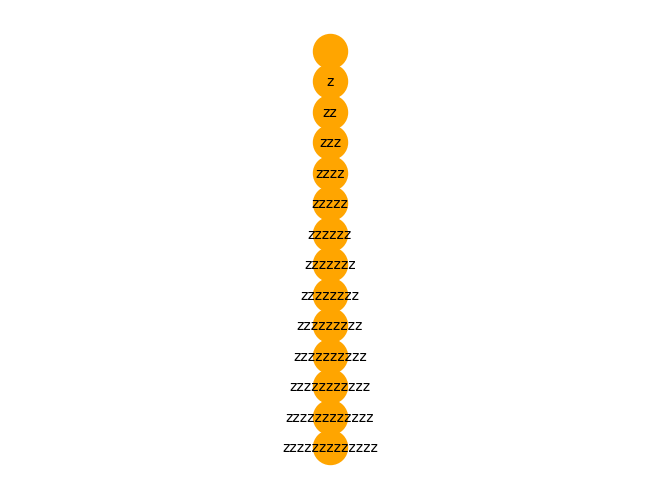

In [14]:
draw_tt(JW_tree, type="spaced")

In [15]:
hamiltonian = molecular_hamiltonian(encoding=JW_tree, one_e_coeffs=one_e_coeffs, two_e_coeffs=two_e_coeffs, constant_energy=e_nuc)
hamiltonian

{'IXZZYYXIIIIIII': (0.0008703795728004278+0j),
 'IIIIYXXYIIIIII': (0.012392510481177663+0j),
 'IIIIIIIIIZIZII': (0.13828434449112778+0j),
 'IXZZZZYYZZXIII': (0.0003239416339179542+0j),
 'IIXYIIIYZZXIII': (0.005571140495075848+0j),
 'XZZZXIXZZZZZXI': (0.0011759293882932765+0j),
 'IZIIIIIZIIIIII': (0.23827963235237104+0j),
 'IIIIIIIIYXXYII': (0.009393863899458905+0j),
 'YXIIIIIIIIXYII': (0.007571676549685402+0j),
 'IIIXYYZZZZXIII': (-0.009107161087955866+0j),
 'IYYIYZZZZZZZZY': (-0.005629286431663927+0j),
 'IIIIIIIXYYXIII': (-6.0492492059029e-07+0j),
 'IXZXIYZZZZZZZY': (-0.005352872663239654+0j),
 'IIIXZZZZZZIXII': (-0.02471111081516574+0j),
 'YZZZYIIIIIIYZY': (0.002169519059087425+0j),
 'IIIYZZZYIIIIII': (-0.1260873393195182+0j),
 'IIIIZIIIIIIIZI': (0.11231833151648227+0j),
 'XXIIIIIIIIYYII': (-0.007571676549685402+0j),
 'XYIIIIIIYXIIII': (0.006505731582038059+0j),
 'XZZZZZZZZZXIIZ': (0.001114858203996733+0j),
 'IIIIZIZIIIIIII': (0.13547051514637634+0j),
 'IIIIIXZZZZZZZX': (-0.369126720

In [16]:
from ferrmion.hamiltonians import molecular_hamiltonian_template

In [17]:
ipowers, symplectics = JW_tree._build_symplectic_matrix()

In [18]:
template = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)

In [19]:
from ferrmion.hamiltonians import fill_template

In [20]:
filled_template = fill_template(template,constant_energy=e_nuc, one_e_coeffs=one_e_coeffs, two_e_coeffs=two_e_coeffs, mode_op_map=JW_tree.default_mode_op_map)
filled_template

{'IXZZZXIIIIYZYI': (0.002169519059087425+0j),
 'IIIIIIIZIIIIII': (1.2973712450027333+0j),
 'IIYZZZYIIIZIII': (-0.0012385928144848838+0j),
 'XZXIYZZZZZZZYI': (-0.005352872663239653+0j),
 'YZZZZZZIZZYIII': (0.0047081255480813915+0j),
 'IXYIIYZZZZZZXI': (0.0035076637416898955+0j),
 'IYXIXYIIIIIIII': (-0.004418371383989492+0j),
 'XZZYIIIIIIYXII': (0.0020619560892495697+0j),
 'IXZZXIIIIIXZZX': (-0.0009644871983424856+0j),
 'IYZYXZZZZZZZXI': (-0.001845208921549757+0j),
 'IIXYIIIIIIIIYX': (0.0157167725706014+0j),
 'IIXZXXZXIIIIII': (-0.005285559978084278+0j),
 'IYZZZZZYIIIIZI': (0.0010617102241055974+0j),
 'IIXZZZZYIIIIYX': (0.004055342411528362+0j),
 'XXIIIIIXZZXIII': (5.061461914464914e-05+0j),
 'IYZZZZZZIZZYII': (0.0014832882799476433+0j),
 'IIIIIYYXZZZZXI': (0.0004423920399374855+0j),
 'IIIIYZZZYYZZZY': (0.0059174661607546775+0j),
 'IIIIIIYZYXZXII': (-6.0492492059029e-07+0j),
 'IXZZZZXIXXIIII': (-0.003376560950360702+0j),
 'IXZYIIIYZZZXII': (0.000500426389472859+0j),
 'IXZZZXIYZZZZZY': (0

In [21]:
assert hamiltonian.keys() == filled_template.keys()
for k in hamiltonian.keys():
    # There is a little numerical instability so 
    # some values are different by 1e-18 or so!
    assert np.isclose(hamiltonian[k], filled_template[k])

In [22]:
one_e_coeffs.shape[0]

14

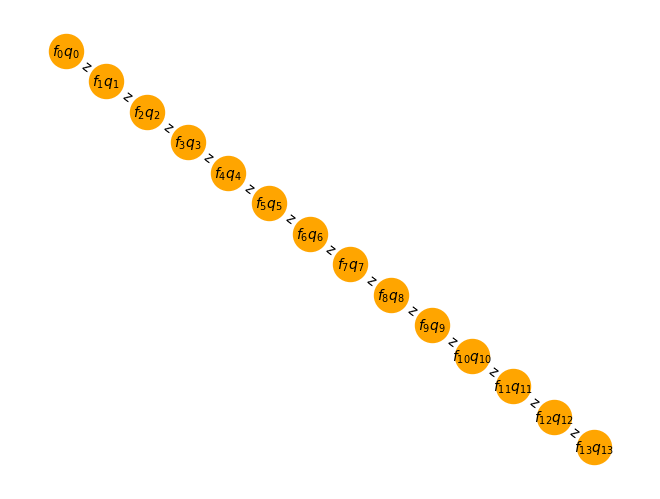

In [23]:
from ferrmion.encode import JordanWigner
from ferrmion.visualise import draw_tt

base_jw = JordanWigner(one_e_coeffs.shape[0])
draw_tt(base_jw, enumeration_scheme=base_jw.default_enumeration_scheme(), type="linear")

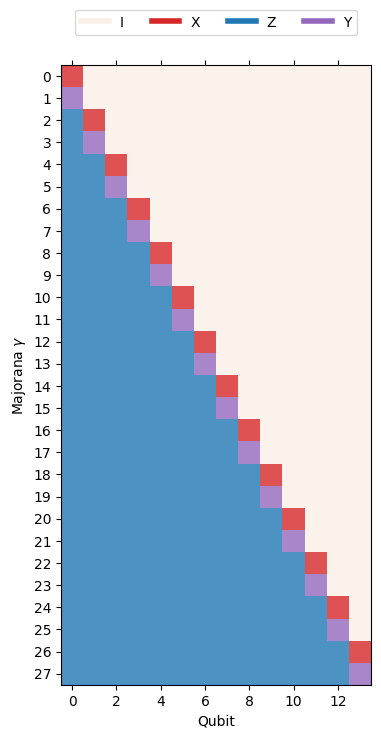

In [24]:
symplectic_matshow(base_jw._build_symplectic_matrix()[1])

In [25]:
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.optimize.topphatt import topphatt
jw_hatt_tree = topphatt(
    majorana_ham = fermionic_to_sparse_majorana(((one_e_coeffs,"+-"), (two_e_coeffs, "++--"))),
    tree = base_jw
)

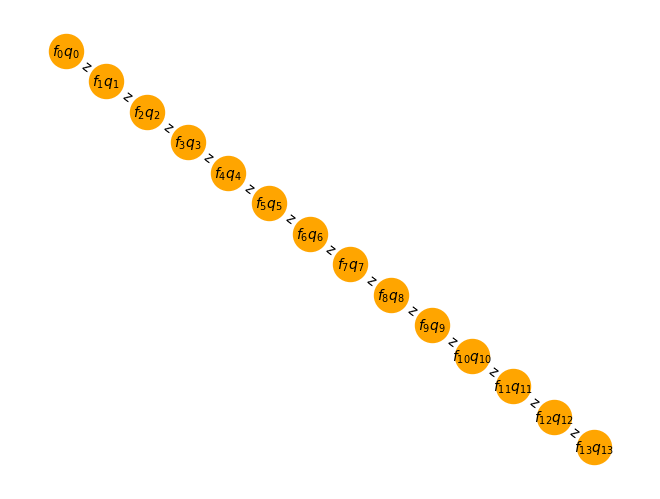

In [26]:
draw_tt(jw_hatt_tree, enumeration_scheme=jw_hatt_tree.default_enumeration_scheme(), type="linear")

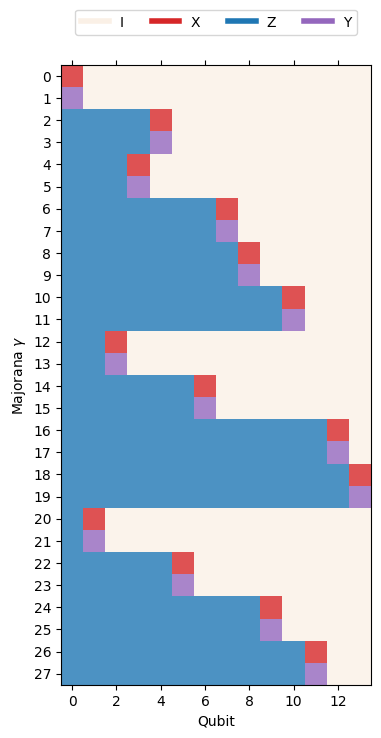

In [27]:
from ferrmion.visualise import symplectic_matshow
symplectic_matshow(jw_hatt_tree._build_symplectic_matrix()[1])

# new funcs

In [29]:
real_ham = make_ham_real(hamiltonian)

In [30]:
qdrift = QDriftSimulation(
    hamiltonian=real_ham,
    duration=0.001
)

In [31]:
qc = qdrift.circuit

In [32]:
qc.depth()

28

In [33]:
qc.draw()

┌───────────────┐┌───────────────┐┌───────────────┐┌───────────────┐»
 q_0: ┤ Rz(0.0077212) ├┤ Rz(0.0077212) ├┤ Rz(0.0077212) ├┤ Rz(0.0077212) ├»
      ├───────────────┤├───────────────┤└───────────────┘└───────────────┘»
 q_1: ┤ Rz(0.0077212) ├┤ Rz(0.0077212) ├──────────────────────────────────»
      └────┬─────┬────┘└─────┬───┬─────┘                                  »
 q_2: ─────┤ Sdg ├───────────┤ H ├──────────────■─────────────────────────»
           └─────┘           └───┘            ┌─┴─┐                       »
 q_3: ────────────────────────────────────────┤ X ├──────────────■────────»
                                              └───┘            ┌─┴─┐      »
 q_4: ─────────────────────────────────────────────────────────┤ X ├──────»
                                                               └───┘      »
 q_5: ────────────────────────────────────────────────────────────────────»
                                                                          »
 q_6: ────────────────────────────────────────────────────────────────────»
                                                                          »
 q_7: ────────────────────────────────────────────────────────────────────»
                                                                          »
 q_8: ────────────────────────────────────────────────────────────────────»
                                                                          »
 q_9: ────────────────────────────────────────────────────────────────────»
           ┌─────┐           ┌───┐                                        »
q_10: ─────┤ Sdg ├───────────┤ H ├────────────────────────────────────────»
           └─────┘           └───┘                                        »
q_11: ────────────────────────────────────────────────────────────────────»
           ┌─────┐           ┌───┐                                        »
q_12: ─────┤ Sdg ├───────────┤ H ├────────────────────────────────────────»
           └─────┘           └───┘                                        »
q_13: ────────────────────────────────────────────────────────────────────»
                                                                          »
«      ┌───────────────┐                                       »
« q_0: ┤ Rz(0.0077212) ├───────────────────────────────────────»
«      └───────────────┘                                       »
« q_1: ────────────────────────────────────────────────────────»
«                       ┌───┐      ┌───┐                       »
« q_2: ────────■────────┤ H ├──────┤ S ├────────────────────■──»
«            ┌─┴─┐      └───┘┌─────┴───┴─────┐ ┌───┐        │  »
« q_3: ──────┤ X ├────────■──┤ Rz(0.0077212) ├─┤ H ├────────┼──»
«            └───┘      ┌─┴─┐└───────────────┘┌┴───┴┐┌───┐┌─┴─┐»
« q_4: ────────■────────┤ X ├────────■────────┤ Sdg ├┤ H ├┤ X ├»
«            ┌─┴─┐      └───┘      ┌─┴─┐      └─────┘└───┘└───┘»
« q_5: ──────┤ X ├────────■────────┤ X ├─────────■─────────────»
«            └───┘      ┌─┴─┐      └───┘       ┌─┴─┐           »
« q_6: ─────────────────┤ X ├────────■─────────┤ X ├───■───────»
«                       └───┘      ┌─┴─┐       └───┘ ┌─┴─┐     »
« q_7: ────────────────────────────┤ X ├─────────■───┤ X ├──■──»
«                                  └───┘       ┌─┴─┐ └───┘┌─┴─┐»
« q_8: ────────────────────────────────────────┤ X ├───■──┤ X ├»
«                                              └───┘ ┌─┴─┐└───┘»
« q_9: ──────────────────────────────────────────────┤ X ├──■──»
«                                                    └───┘┌─┴─┐»
«q_10: ───────────────────────────────────────────────────┤ X ├»
«                                                         └───┘»
«q_11: ────────────────────────────────────────────────────────»
«                                                              »
«q_12: ────────────────────────────────────────────────────────»
«                                                              »
«q_13: ────────────────────────────────────────

In [34]:
from ferrmion.utils import fermionic_to_sparse_majorana

In [35]:
majorana_ham = fermionic_to_sparse_majorana([(one_e_coeffs, "+-"), (two_e_coeffs, "++--")])
majorana_ham

{(0, 1): np.complex128(-12.411384496926367j),
 (0, 4): np.complex128(3.907464629637758e-16+0j),
 (0, 5): np.complex128(0.229608628985289j),
 (1, 4): np.complex128(-0.229608628985289j),
 (1, 5): np.complex128(3.907464629637758e-16+0j),
 (0, 12): np.complex128(1.0907073855204175e-16+0j),
 (0, 13): np.complex128(0.09912613051620611j),
 (1, 12): np.complex128(-0.09912613051620614j),
 (1, 13): np.complex128(1.0993810029003015e-16+0j),
 (0, 21): np.complex128(0.14145198484879912j),
 (1, 20): np.complex128(-0.14145198484879917j),
 (2, 3): np.complex128(-12.411384496926367j),
 (2, 6): np.complex128(3.7990444123892075e-16+0j),
 (2, 7): np.complex128(0.1283272284140795j),
 (3, 6): np.complex128(-0.1283272284140795j),
 (3, 7): np.complex128(3.7296554733501353e-16+0j),
 (2, 15): np.complex128(0.05023431498823723j),
 (3, 14): np.complex128(-0.05023431498823726j),
 (3, 15): np.complex128(1.0993810029003015e-16+0j),
 (2, 23): np.complex128(0.08270953315309322j),
 (3, 22): np.complex128(-0.08270953315

In [36]:
from typing import Iterable
from ferrmion.optimize.hatt import _reduce_hamiltonian

def jw_hatt(
    majorana_ham: dict[Iterable[int], float], n_modes: int, coeff_weight:bool=False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}

    n_leaves = 2*n_modes +1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves+ i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves  + n_modes)}

    total_weight = 0
    for i in range(n_modes+1):
        print(f"{len(unassigned)=}, {unassigned=}")
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        # reverse because best is usually at the end 
        # reversed_combinations = [c for c in combinations(unassigned, 2)]

        # Z-child of new node will always be the previous node.
        # We only need to use every second entry in unassigned
        # as we already order odd/even terms
        # we also know for jw that every new node will be
        # the z-ancestor all all other nodes.
        z_index = unassigned[0]
        for x_index in unassigned[1::2]:
            small_y = None
            small_x = None
            # Now that we are enforcing a topology
            # we actually need to set the combination
            comb = z_index, x_index

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # ) 
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # elif weight == min_weight:
            # #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
            #     min_weight = weight
            #     selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        # print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [ u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned
        
        if i +1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print(total_weight)
    return tree

In [37]:
from ferrmion.utils import fermionic_to_sparse_majorana
jw_hatt_tree = jw_hatt(fermionic_to_sparse_majorana(((one_e_coeffs,"+-"), (two_e_coeffs, "++--"))), n_modes=one_e_coeffs.shape[0], coeff_weight=False)

len(unassigned)=29, unassigned=[28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=27, unassigned=[29, 27, 26, 25, 24, 23, 22, 21, 20, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=25, unassigned=[30, 27, 26, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=23, unassigned=[31, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=21, unassigned=[32, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=19, unassigned=[33, 23, 22, 21, 20, 15, 14, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=17, unassigned=[34, 23, 22, 21, 20, 15, 14, 13, 12, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=15, unassigned=[35, 23, 22, 21, 20, 15, 14, 13, 12, 5, 4, 3, 2, 1, 0]
len(unassigned)=13, unassigned=[36, 23, 22, 21, 20, 13, 12, 5, 4, 3, 2, 1, 0]
len(unassigned)=11, unassigned=[37, 

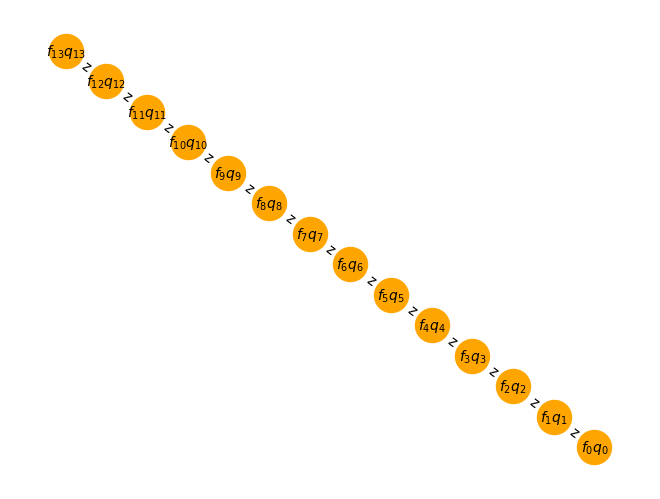

In [38]:
draw_tt(jw_hatt_tree, enumeration_scheme=jw_hatt_tree.default_enumeration_scheme(), type="linear")

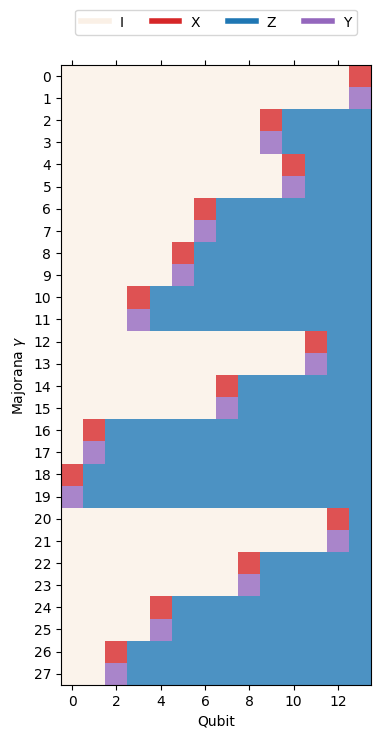

In [39]:
from ferrmion.visualise import symplectic_matshow
symplectic_matshow(jw_hatt_tree._build_symplectic_matrix()[1])

In [12]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (unscaled_terms, scaled_terms, len(pauli_hamiltonian))

In [13]:
def fill_template_find_norms(template, ones, twos, permutation):
    permutation = np.array(permutation, dtype=np.uint)
    ham = fill_template(template, 0, ones, twos, permutation)
    
    return pauli_weights(ham)

In [10]:
from ferrmion.optimize.topphatt import topphatt

In [43]:
th_tree = topphatt(
    majorana_ham=majorana_ham,
    tree=jw_hatt_tree
)

In [44]:
th_tree.pauli_weight

2301

In [45]:
th_ham = molecular_hamiltonian(
    encoding=th_tree,
    one_e_coeffs=one_e_coeffs,
    two_e_coeffs=two_e_coeffs,
    constant_energy=e_nuc,
)

In [46]:
th_ham

{'IIIIIZXZXIIIII': (-0.03874057471228172+0j),
 'IYZZZZZZZZZZIY': (-0.024631545995852926+0j),
 'IZIIIIIIIIZIII': (0.12507770062013723+0j),
 'IIYZZZZZYIIIII': (0.12500059285065607+0j),
 'IYZZZZZZZZZXXY': (-0.0004397032446309102+0j),
 'IIZIIIXZXIIIII': (-0.06629310906999393+0j),
 'IIXXIYZZZZZYII': (0.003376560950360702+0j),
 'IIYZZZYIIIIZII': (0.004708125548081391+0j),
 'IIIIIIXXIIYYII': (0.019419935619344866+0j),
 'IIIIXZZIZZXIII': (0.0047081255480813915+0j),
 'IIIYXXYIIIIIII': (-0.0037341125974757715+0j),
 'YZZZZZZYIIIYZY': (-0.00044239203993748545+0j),
 'ZIIIIIIIIIXZXI': (-0.018983599635609336+0j),
 'IIZIIIIIIIIIII': (12.411384496926361+0j),
 'IIIIIIIIIIYYZI': (0.019849993760979512+0j),
 'IIIZIIIIIIIIII': (1.3666273515257572+0j),
 'YXIIIIIIXZYIII': (-0.009107161087955866+0j),
 'XYIYZXIIIIIIII': (0.007104042351954914+0j),
 'ZIIIIIIIIIIIIZ': (0.15116338796931794+0j),
 'IIIIIIIIIIYYII': (0.23951132205821515+0j),
 'IZYZZZZZYIIIII': (0.001120008011584996+0j),
 'XZXIIIIYZYIIII': (0.001175929

In [47]:
th_ham_real = make_ham_real(th_ham)

In [48]:
qdrift = QDriftSimulation(
    hamiltonian=th_ham_real,
    duration=0.001
)

In [49]:
qc = qdrift.circuit

In [50]:
qc.depth()

49

In [51]:
np.sum(pauli_weights(th_ham)[1])

np.float64(184.54896577549889)

In [53]:
real_symmer = make_ham_real(nbed_ham_symmer_dict)

In [54]:
qdrift = QDriftSimulation(
    hamiltonian=real_ham,
    duration=0.001
)

In [55]:
qc = qdrift.circuit

In [56]:
qc.depth()

39

# comparisons

In [8]:
def compare_qdrift_circuit(
        one_e_coeffs, 
        two_e_coeffs, 
        constant_energy,
        duration
    ):
    
    tt = TernaryTree.from_hamiltonian_coefficients((one_e_coeffs, two_e_coeffs))
    jw = tt.JW()
    jw.enumeration_scheme = jw.default_enumeration_scheme()

    JW_ham = molecular_hamiltonian(
        encoding=jw, 
        one_e_coeffs=one_e_coeffs, 
        two_e_coeffs=two_e_coeffs, 
        constant_energy=constant_energy
    )

    JW_ham = make_ham_real(JW_ham)

    majorana_ham = fermionic_to_sparse_majorana(
        [(one_e_coeffs, "+-"), (two_e_coeffs, "++--")]
    )

    TH_tree = topphatt(
        majorana_ham=majorana_ham,
        tree=jw
    )

    TH_ham = molecular_hamiltonian(
        encoding=TH_tree,
        one_e_coeffs=one_e_coeffs,
        two_e_coeffs=two_e_coeffs,
        constant_energy=constant_energy,
    )

    TH_ham = make_ham_real(TH_ham)

    JW_weights = pauli_weights(JW_ham)
    TH_weights = pauli_weights(TH_ham)

    JW_lambda = float(np.sum(np.abs(JW_weights[1])))
    TH_lambda = float(np.sum(np.abs(TH_weights[1])))

    print("mean JW weights:", int(np.mean(JW_weights[0])), float(np.mean(JW_weights[1])), int(JW_weights[2]))
    print("mean TH weights:", int(np.mean(TH_weights[0])), float(np.mean(TH_weights[1])), int(TH_weights[2]))

    print('JW lambda^2:', JW_lambda**2)
    print('TH lambda^2:', TH_lambda**2)

    factor = JW_lambda**2 / TH_lambda**2

    print('TH shoud be smaller by factor:', factor)

    QD_JW = QDriftSimulation(
        hamiltonian=JW_ham,
        duration=duration
    )

    QD_TH = QDriftSimulation(
        hamiltonian=TH_ham,
        duration=duration
    )

    return QD_JW.circuit.depth(), QD_TH.circuit.depth(), factor

In [140]:
JW_depth, TH_depth, _ = compare_qdrift_circuit(
    one_e_coeffs, 
    two_e_coeffs, 
    e_nuc,
    duration=0.01
    )

mean JW weights: 4 0.15920861405147013 185
mean TH weights: 3 0.13591401008414739 185
JW lambda^2: 867.5141759258017
TH lambda^2: 632.225355744086
TH shoud be smaller by factor: 1.3721597339366387


In [141]:
JW_depth

72

In [142]:
TH_depth

70

In [143]:
print(JW_depth / TH_depth)

1.0285714285714285


In [144]:
mol_obj = pyscf.M(
    atom = 'H 0 0 0; H 0 0 1',
    basis = '6-31g'
)

rhf_obj = pyscf.scf.RHF(mol_obj).run()

e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

converged SCF energy = -1.09480796286051


In [145]:
repeats = 10

results = {}

for i in range(repeats):
    results[i] = {}

    JW_depths = []
    TH_depths = []

    JW_depth, TH_depth, factor = compare_qdrift_circuit(
        one_e_coeffs, 
        two_e_coeffs, 
        e_nuc,
        duration=0.01
        )
    
    results[i]['JW'] = JW_depth
    results[i]['TH'] = TH_depth
    results[i]['factor'] = factor
    results[i]['ratio'] = JW_depth / TH_depth

    print('done repeat', i)

mean JW weights: 4 0.15920861405147013 185
mean TH weights: 3 0.13591401008414739 185
JW lambda^2: 867.514175925802
TH lambda^2: 632.225355744086
TH shoud be smaller by factor: 1.3721597339366391
done repeat 0
mean JW weights: 4 0.15920861405147013 185
mean TH weights: 3 0.13591401008414739 185
JW lambda^2: 867.5141759258017
TH lambda^2: 632.225355744086
TH shoud be smaller by factor: 1.3721597339366387
done repeat 1
mean JW weights: 4 0.15920861405147013 185
mean TH weights: 3 0.13591401008414739 185
JW lambda^2: 867.5141759258017
TH lambda^2: 632.225355744086
TH shoud be smaller by factor: 1.3721597339366387
done repeat 2
mean JW weights: 4 0.15920861405147013 185
mean TH weights: 3 0.13591401008414739 185
JW lambda^2: 867.514175925802
TH lambda^2: 632.225355744086
TH shoud be smaller by factor: 1.3721597339366391
done repeat 3
mean JW weights: 4 0.15920861405147013 185
mean TH weights: 3 0.13591401008414739 185
JW lambda^2: 867.514175925802
TH lambda^2: 632.225355744086
TH shoud be 

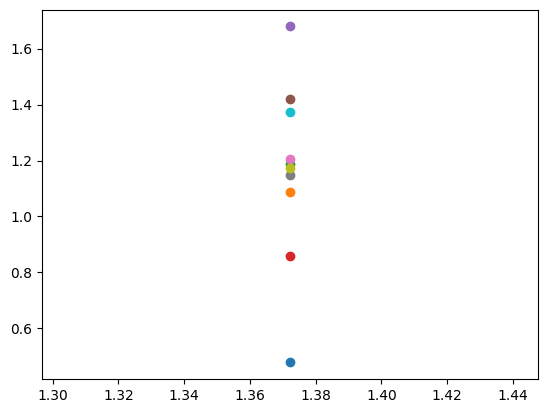

In [146]:
for result in results:
    data = results[result]

    plt.scatter(data['factor'], data['ratio'])

plt.show()

In [4]:
mol_obj = pyscf.M(
    atom = 'mols/H2O.xyz',
    basis = 'sto-3g'
)

rhf_obj = pyscf.scf.RHF(mol_obj).run()

e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

converged SCF energy = -74.9659011922597


In [150]:
JW_depth, TH_depth, _ = compare_qdrift_circuit(
    one_e_coeffs, 
    two_e_coeffs, 
    e_nuc,
    duration=0.001
    )

mean JW weights: 7 0.17621337145046764 1086
mean TH weights: 4 0.12705021266991032 1086
JW lambda^2: 36621.6047919939
TH lambda^2: 19037.523095624096
TH shoud be smaller by factor: 1.9236538602236353


In [151]:
JW_depth

24

In [152]:
TH_depth

26

In [6]:
depths = np.arange(0.001, 0.011, 0.001)
depths

array([0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009,
       0.01 ])

In [186]:
import time

mol_obj = pyscf.M(
    atom = 'Li 0 0 0; H 0 0 1.0',
    basis = 'sto-3g'
)

rhf_obj = pyscf.scf.RHF(mol_obj).run()

e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

JW_depths = []
TH_depths = []

depth = 0.001

while True:
    start_time = time.time()
    JW_d, TH_d, _ = compare_qdrift_circuit(
        one_e_coeffs, 
        two_e_coeffs, 
        e_nuc,
        duration=depth
        )
    end_time = time.time()
    JW_depths.append(JW_d)
    TH_depths.append(TH_d)
    print('done', depth)
    if end_time - start_time > 2.0:
        break
    depth += 0.001


converged SCF energy = -7.76736213574855
mean JW weights: 6 0.05585384833836522 631
mean TH weights: 4 0.04856327893448421 631
JW lambda^2: 1242.1239089658782
TH lambda^2: 939.0197413474698
TH shoud be smaller by factor: 1.3227878544741365
done 0.001
mean JW weights: 6 0.05585384833836522 631
mean TH weights: 4 0.04856327893448421 631
JW lambda^2: 1242.1239089658782
TH lambda^2: 939.0197413474698
TH shoud be smaller by factor: 1.3227878544741365
done 0.002
mean JW weights: 6 0.05585384833836522 631
mean TH weights: 4 0.04856327893448421 631
JW lambda^2: 1242.1239089658782
TH lambda^2: 939.0197413474698
TH shoud be smaller by factor: 1.3227878544741365
done 0.003
mean JW weights: 6 0.05585384833836522 631
mean TH weights: 4 0.04856327893448421 631
JW lambda^2: 1242.1239089658782
TH lambda^2: 939.0197413474698
TH shoud be smaller by factor: 1.3227878544741365
done 0.004
mean JW weights: 6 0.05585384833836522 631
mean TH weights: 4 0.04856327893448421 631
JW lambda^2: 1242.1239089658782
T

In [187]:
depths = np.arange(0.001, depth, 0.001)

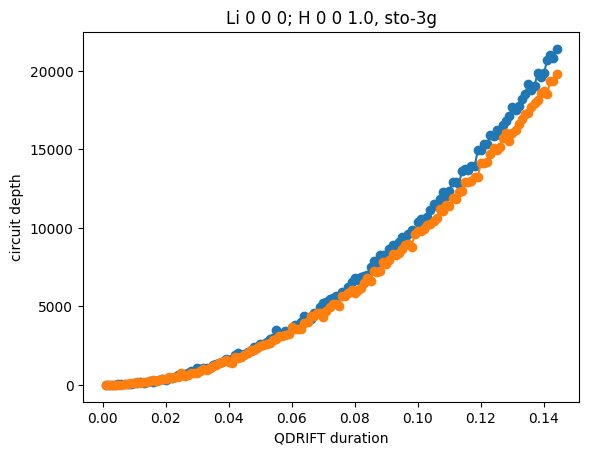

In [188]:
plt.plot(depths, JW_depths, label='JW', marker='o')
plt.plot(depths, TH_depths, label='TH', marker='o')

plt.xlabel('QDRIFT duration')
plt.ylabel('circuit depth')
plt.title(', '.join([mol_obj.atom, mol_obj.basis]))

plt.show()

In [15]:
repeats = 10

results = {}

for i in range(repeats):
    results[i] = {}

    JW_depths = []
    TH_depths = []

    for depth in depths:
        JW_d, TH_d, _ = compare_qdrift_circuit(
            one_e_coeffs, 
            two_e_coeffs, 
            e_nuc,
            duration=depth
            )
        JW_depths.append(JW_d)
        TH_depths.append(TH_d)
    
    results[i]['JW'] = JW_depths
    results[i]['TH'] = TH_depths

    print('done repeat', i)

mean JW weights: 7 0.17621337145046764 1086
mean TH weights: 4 0.12705021266991032 1086
JW lambda^2: 36621.6047919939
TH lambda^2: 19037.523095624096
TH shoud be smaller by factor: 1.9236538602236353
mean JW weights: 7 0.17621337145046764 1086
mean TH weights: 4 0.12705021266991032 1086
JW lambda^2: 36621.6047919939
TH lambda^2: 19037.523095624096
TH shoud be smaller by factor: 1.9236538602236353
mean JW weights: 7 0.17621337145046767 1086
mean TH weights: 4 0.12705021266991032 1086
JW lambda^2: 36621.60479199391
TH lambda^2: 19037.523095624096
TH shoud be smaller by factor: 1.9236538602236355
mean JW weights: 7 0.17621337145046764 1086
mean TH weights: 4 0.12705021266991032 1086
JW lambda^2: 36621.6047919939
TH lambda^2: 19037.523095624096
TH shoud be smaller by factor: 1.9236538602236353
mean JW weights: 7 0.17621337145046764 1086
mean TH weights: 4 0.12705021266991032 1086
JW lambda^2: 36621.6047919939
TH lambda^2: 19037.523095624096
TH shoud be smaller by factor: 1.9236538602236353

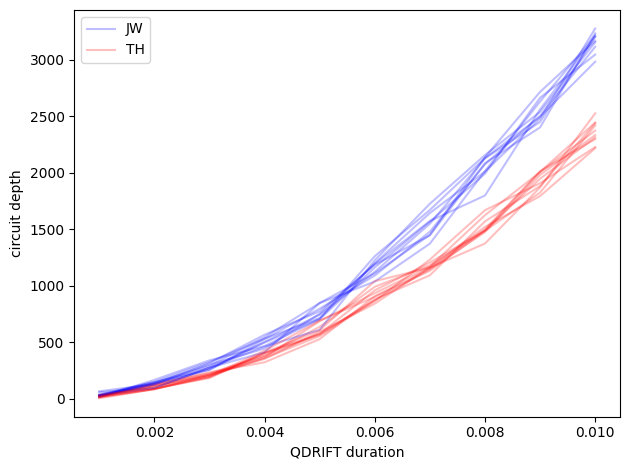

In [18]:
for result in results:
    data = results[result]

    if result == 0:
        plt.plot(depths, data['JW'], label='JW', alpha=0.25, color='blue')
        plt.plot(depths, data['TH'], label='TH', alpha=0.25, color='red')
    else:
        plt.plot(depths, data['JW'], alpha=0.25, color='blue')
        plt.plot(depths, data['TH'], alpha=0.25, color='red')

plt.legend()

plt.xlabel('QDRIFT duration')
plt.ylabel('circuit depth')
# plt.title(', '.join([mol_obj.atom, mol_obj.basis]))

plt.tight_layout()

plt.savefig('qdrift_depths_water.pdf')

plt.show()

In [189]:
# qdrift sampling:


In [192]:
from symmer import PauliwordOp

In [193]:
def sample_hamiltonian(H: PauliwordOp, t:float=1, eps:float=None, N:int=None) -> PauliwordOp:
    # qDRIFT sampling scheme:
    Lambda = np.linalg.norm(H.coeff_vec, ord=1)
    if N is None:
        assert eps is not None, 'Need to specify eps, the target Trotter error'
        N = int(np.ceil(2*Lambda**2*t**2/eps))
    tau = Lambda*t/N
    # sample from coefficient distribution
    ham_coeff_dist = abs(H.coeff_vec)/Lambda
    sampled_layer_indices = np.random.choice(np.arange(H.n_terms),N,p=ham_coeff_dist)
    H_sampled = H[sampled_layer_indices]
    H_sampled.coeff_vec = np.sign(H_sampled.coeff_vec) * tau
    return H_sampled

In [195]:
mol_obj = pyscf.M(
    atom = 'H2O.xyz',
    basis = 'sto-3g'
)

rhf_obj = pyscf.scf.RHF(mol_obj).run()

e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

converged SCF energy = -74.9659011922597


In [196]:
tt = TernaryTree.from_hamiltonian_coefficients((one_e_coeffs, two_e_coeffs))
jw = tt.JW()
jw.enumeration_scheme = jw.default_enumeration_scheme()

JW_ham = molecular_hamiltonian(
    encoding=jw, 
    one_e_coeffs=one_e_coeffs, 
    two_e_coeffs=two_e_coeffs, 
    constant_energy=e_nuc
)

JW_ham = make_ham_real(JW_ham)

majorana_ham = fermionic_to_sparse_majorana(
    [(one_e_coeffs, "+-"), (two_e_coeffs, "++--")]
)

TH_tree = topphatt(
    majorana_ham=majorana_ham,
    tree=jw
)

TH_ham = molecular_hamiltonian(
    encoding=TH_tree,
    one_e_coeffs=one_e_coeffs,
    two_e_coeffs=two_e_coeffs,
    constant_energy=e_nuc,
)

TH_ham = make_ham_real(TH_ham)

JW_weights = pauli_weights(JW_ham)
TH_weights = pauli_weights(TH_ham)

print("JW weights:", int(np.sum(JW_weights[0])), float(np.sum(JW_weights[1])), int(JW_weights[2]))
print("TH weights:", int(np.sum(TH_weights[0])), float(np.sum(TH_weights[1])), int(TH_weights[2]))

JW weights: 7664 191.36772139520787 1086
TH weights: 5404 137.9765309595226 1086


In [200]:
JW_ham_symmer = PauliwordOp.from_dictionary(JW_ham)
TH_ham_symmer = PauliwordOp.from_dictionary(TH_ham)

In [206]:
JW_ham_sampled = sample_hamiltonian(JW_ham_symmer, t=0.01, eps=0.001)
TH_ham_sampled = sample_hamiltonian(TH_ham_symmer, t=0.01, eps=0.001)

In [207]:
JW_ham_sampled.n_terms

3247

In [208]:
TH_ham_sampled.n_terms

3247

In [212]:
TH_ham_symmer.sort()

-55.445+0.000j IIIIIIIIIIIIII +
 12.411+0.000j ZIIIIIIIIIIIII +
 12.411+0.000j IIIIZIIIIIIIII +
 1.650+0.000j IIIZIIIIIIIIII +
 1.650+0.000j IIIIIIIZIIIIII +
 1.367+0.000j IIIIIIIIIIIIIZ +
 1.367+0.000j IIIIIIIIIIIIZI +
 1.297+0.000j IIIIIIZIIIIIII +
 1.297+0.000j IIZIIIIIIIIIII +
 1.191+0.000j IIIIIIIIZIIIII +
 1.191+0.000j IIIIIIIIIIZIII +
 1.186+0.000j ZIIIZIIIIIIIII +
 0.811+0.000j IIIIIIIIIZIIII +
 0.811+0.000j IIIIIIIIIIIZII +
 0.793+0.000j IZIIIIIIIIIIII +
 0.793+0.000j IIIIIZIIIIIIII +
-0.369+0.000j IIIIIIIIIIXXII +
-0.369+0.000j IIIIIIIIXXIIII +
-0.369+0.000j IIIIIIIIIIYYII +
-0.369+0.000j IIIIIIIIYYIIII +
 0.279+0.000j IIIIZIIIIIIIZI +
 0.279+0.000j ZIIIIIIIIIIIIZ +
-0.276+0.000j IIIIIYZYIIIIII +
-0.276+0.000j IYZYIIIIIIIIII +
-0.276+0.000j IIIIIXZXIIIIII +
-0.276+0.000j IXZXIIIIIIIIII +
 0.272+0.000j IIIIZIIIIIIIIZ +
 0.272+0.000j ZIIIIIIIIIIIZI +
 0.252+0.000j ZIIIIIIZIIIIII +
 0.252+0.000j IIIZZIIIIIIIII +
 0.245+0.000j IIZIZIIIIIIIII +
 0.245+0.000j ZIIIIIZIIIIIII +
 0.24

In [213]:
JW_ham_symmer.sort()

-55.445+0.000j IIIIIIIIIIIIII +
 12.411+0.000j IZIIIIIIIIIIII +
 12.411+0.000j ZIIIIIIIIIIIII +
 1.650+0.000j IIIZIIIIIIIIII +
 1.650+0.000j IIZIIIIIIIIIII +
 1.367+0.000j IIIIIIIIIZIIII +
 1.367+0.000j IIIIIIIIZIIIII +
 1.297+0.000j IIIIIIIZIIIIII +
 1.297+0.000j IIIIIIZIIIIIII +
 1.191+0.000j IIIIZIIIIIIIII +
 1.191+0.000j IIIIIZIIIIIIII +
 1.186+0.000j ZZIIIIIIIIIIII +
 0.811+0.000j IIIIIIIIIIIIZI +
 0.811+0.000j IIIIIIIIIIIIIZ +
 0.793+0.000j IIIIIIIIIIZIII +
 0.793+0.000j IIIIIIIIIIIZII +
-0.369+0.000j IIIIIXZZZZZZZX +
-0.369+0.000j IIIIYZZZZZZZYI +
-0.369+0.000j IIIIIYZZZZZZZY +
-0.369+0.000j IIIIXZZZZZZZXI +
 0.279+0.000j ZIIIIIIIIZIIII +
 0.279+0.000j IZIIIIIIZIIIII +
-0.276+0.000j IIYZZZZZZZYIII +
-0.276+0.000j IIIYZZZZZZZYII +
-0.276+0.000j IIXZZZZZZZXIII +
-0.276+0.000j IIIXZZZZZZZXII +
 0.272+0.000j IZIIIIIIIZIIII +
 0.272+0.000j ZIIIIIIIZIIIII +
 0.252+0.000j ZIIZIIIIIIIIII +
 0.252+0.000j IZZIIIIIIIIIII +
 0.245+0.000j ZIIIIIIZIIIIII +
 0.245+0.000j IZIIIIZIIIIIII +
 0.24

In [218]:
symplectic_matshow(JW_ham._build_symplectic_matrix()[1])

AttributeError: 'dict' object has no attribute '_build_symplectic_matrix'

# IBM device

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
  token="insert new key",
  )
 
service.backends()

qiskit_runtime_service._discover_account:WARNING:2025-11-11 12:35:55,565: Loading account with the given token. A saved account will not be used.
session._log_request_info:DEBUG:2025-11-11 12:35:58,420: Endpoint: https://quantum.cloud.ibm.com/api/v1/backends. Method: GET. 
qiskit_runtime_service.__init__:WARNING:2025-11-11 12:35:59,279: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium), the available account instances are: CHM218. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-11-11 12:35:59,280: Loading instance: CHM218, plan: premium
session._log_request_info:DEBUG:2025-11-11 12:35:59,307: Endpoint: https://quantum.cloud.ibm.com/api/v1/backends/.../configuration. Method: GET. 


[<IBMBackend('ibm_pittsburgh')>,
 <IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_torino')>,
 <IBMBackend('ibm_kingston')>]

In [146]:
backend = service.backend('ibm_pittsburgh')

qiskit_runtime_service.backends:WARNING:2025-11-11 12:36:02,771: Using instance: CHM218, plan: premium


In [147]:
backend

<IBMBackend('ibm_pittsburgh')>

In [148]:
import rustworkx as rx

In [149]:
coupling_map = backend.coupling_map
num_qubits = backend.configuration().num_qubits

In [150]:
coupling_map.graph

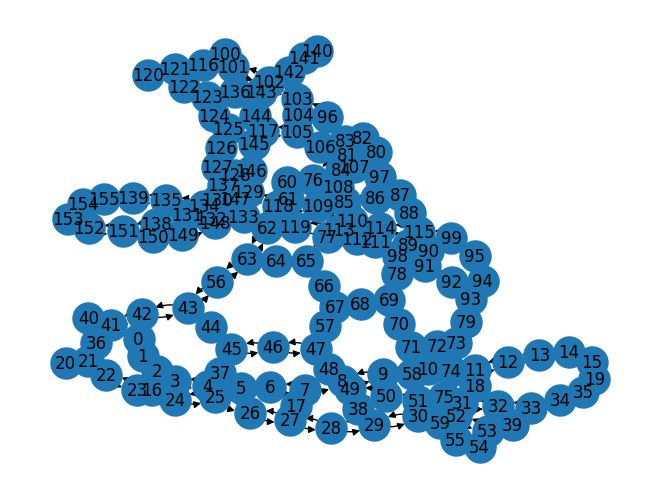

In [151]:
coupling_map = backend.coupling_map
num_qubits = backend.configuration().num_qubits

graph = coupling_map.graph

pos = rx.spring_layout(graph, seed=989)

rx.visualization.mpl_draw(graph, pos=pos, with_labels=True, node_size=500)

In [152]:
distances = rx.distance_matrix(graph)
distances

array([[ 0.,  1.,  2., ..., 31., 30., 29.],
       [ 1.,  0.,  1., ..., 30., 29., 28.],
       [ 2.,  1.,  0., ..., 29., 28., 27.],
       ...,
       [31., 30., 29., ...,  0.,  1.,  2.],
       [30., 29., 28., ...,  1.,  0.,  1.],
       [29., 28., 27., ...,  2.,  1.,  0.]], shape=(156, 156))

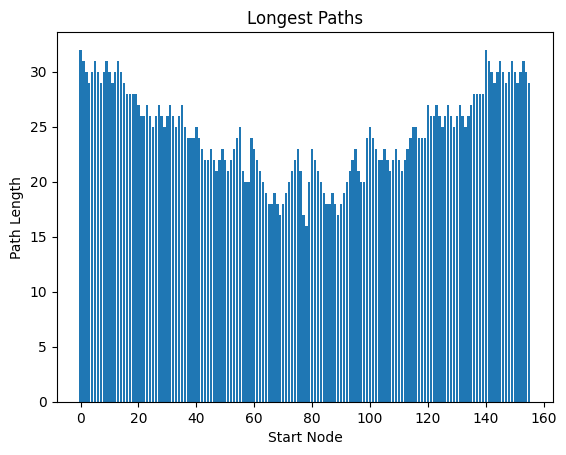

In [153]:
plt.bar([*range(distances.shape[1])], np.max(distances, axis=1))
plt.title("Longest Paths")
plt.xlabel("Start Node")
plt.ylabel("Path Length")
plt.show()

In [154]:
from ferrmion.encode.ternary_tree_node import TTNode
from enum import Enum
import numpy as np

# First we find the root 
root_index = np.argmin(np.max(distances, axis=1))
node_queue = [root_index]
used_indices = {root_index}

# Set values for the root node.
nodes = [TTNode(parent=None) for _ in range(graph.num_nodes())]
nodes[root_index].root_path = ""
nodes[root_index].qubit_label = root_index

In [160]:
root_index

np.int64(78)

In [161]:
class LabellingTypes(Enum):
    HOM="homogenous"
    HET="heterogenous"

labelling = LabellingTypes("homogenous")

In [162]:
while len(node_queue)>0:
    node=node_queue.pop(0)
    parent = nodes[node]

    match labelling:
        case LabellingTypes.HOM:
            chars = ["x","y","z"]
        case LabellingTypes.HET:
            chars = ["z","x","y"]
    
    neighbors= list(set(graph.neighbors(node)).difference(used_indices))

    for child in neighbors[:3]:
        node_queue.append(child)
        used_indices.add(child)

    n_neighbors = len(neighbors)
    for neighbor, char in zip(neighbors[:3], chars[:n_neighbors]):
        parent.add_child(char, child_node=nodes[neighbor], root_path=f"{parent.root_path}{char}", qubit_label=neighbor)
        nodes[neighbor].parent = parent

In [163]:
if len(used_indices) == graph.num_nodes():
    print("Tree spans the graph!")
else:
    print("Tree does not span the graph!")
    unused_indices = set(range(graph.num_nodes())).difference(used_indices)
    for unused in unused_indices:
        closest = np.argsort(distances[unused])
        for used in closest:
            used_node: TTNode = nodes[used]
            for child_branch in chars:
                if getattr(used_node, child_branch) is None:
                    used_node.add_child(child_branch, child_node=nodes[unused], root_path=f"{used_node.root_path}{child_branch}", qubit_label=unused)
                    unused_indices.remove(used)
                    break
    if len(unused_indices) > 0:
        print("Error, not all qubits assigned to nodes.")

Tree spans the graph!


In [ ]:
bonsai = TernaryTree(graph.num_nodes(), root_node=nodes[root_index])
bonsai.enumeration_scheme = bonsai.default_enumeration_scheme()

In [138]:
draw_tt(
    bonsai, 
    type="spaced", 
    enumeration_scheme=bonsai.default_enumeration_scheme()
)

NameError: name 'bonsai' is not defined

## IQM

In [3]:
import networkx as nx
import rustworkx as rx
import matplotlib.pyplot as plt
import numpy as np
from enum import Enum

from ferrmion.encode.ternary_tree_node import TTNode
from ferrmion import TernaryTree
from ferrmion.visualise import draw_tt

class LabellingTypes(Enum):
    HOM="homogenous"
    HET="heterogenous"

labelling = LabellingTypes("homogenous")

In [4]:
emerald_edges = [(0, 1),
    (0, 4),
    (3, 2),
    (3, 4),
    (3, 9),
    (5, 1),
    (5, 4),
    (5, 6),
    (5, 11),
    (8, 2),
    (8, 7),
    (8, 9),
    (8, 16),
    (10, 4),
    (10, 9),
    (10, 11),
    (10, 18),
    (12, 11),
    (12, 13),
    (12, 20),
    (15, 7),
    (15, 14),
    (15, 16),
    (15, 23),
    (17, 16),
    (17, 18),
    (17, 25),
    (18, 26),
    (19, 11),
    (19, 18),
    (19, 20),
    (19, 27),
    (21, 13),
    (21, 20),
    (21, 29),
    (22, 14),
    (22, 23),
    (24, 16),
    (24, 23),
    (24, 25),
    (24, 32),
    (25, 26),
    (26, 27),
    (26, 34),
    (28, 20),
    (28, 27),
    (28, 29),
    (28, 36),
    (30, 29),
    (30, 38),
    (31, 23),
    (31, 32),
    (33, 25),
    (33, 32),
    (33, 34),
    (33, 41),
    (34, 42),
    (35, 27),
    (35, 34),
    (35, 36),
    (35, 43),
    (36, 37),
    (37, 38),
    (37, 45),
    (40, 32),
    (40, 39),
    (40, 41),
    (40, 46),
    (41, 42),
    (43, 49),
    (44, 36),
    (44, 43),
    (44, 45),
    (44, 50),
    (47, 41),
    (47, 46),
    (47, 48),
    (47, 51),
    (49, 50),
    (49, 53),
    (52, 48),
    (52, 51),
    (52, 53)
]

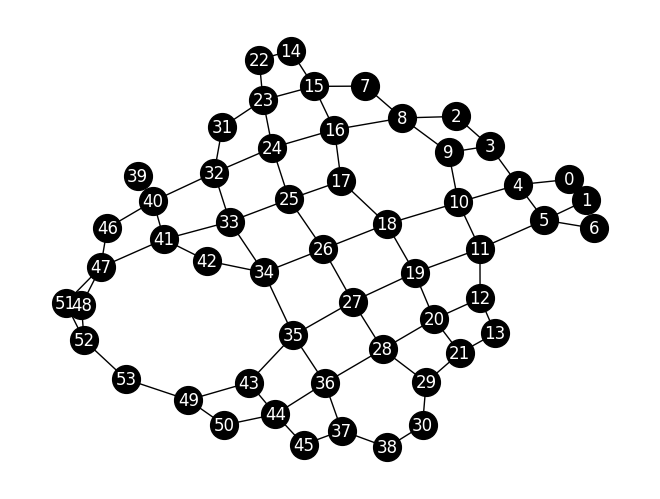

In [5]:
# networkx graph from edges

emerald_graph_nx = nx.Graph()
emerald_graph_nx.add_edges_from(emerald_edges)
layout = nx.spring_layout(emerald_graph_nx, seed=6)

nx.draw(
    G = emerald_graph_nx, 
    pos = layout, 
    node_color = 'black', 
    node_size = 400, 
    with_labels = True, 
    font_color = "white"
)

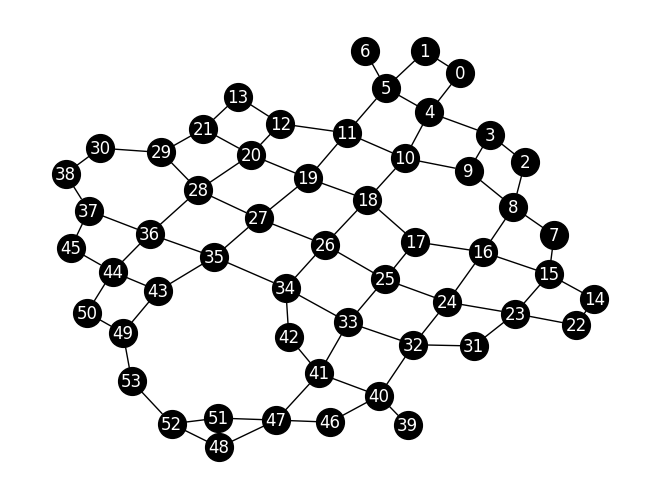

In [6]:
#rustworkx graph from edges (the actual input for bonsai)

emerald_graph_rx = rx.PyGraph()
num_qubits = max(max(pair) for pair in emerald_edges) + 1
emerald_graph_rx.add_nodes_from(range(num_qubits))
emerald_graph_rx.add_edges_from_no_data(emerald_edges)

rx.visualization.mpl_draw(
    graph = emerald_graph_rx, 
    with_labels = True,
    node_color = 'black',
    node_size = 400,
    font_color = 'white',
    pos = rx.spring_layout(emerald_graph_rx, seed=5)
)

In [7]:
graph = emerald_graph_rx

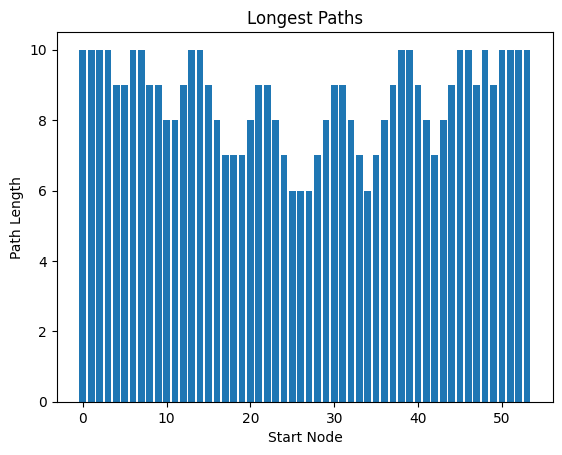

In [8]:
distances = rx.distance_matrix(graph)

plt.bar([*range(distances.shape[1])], np.max(distances, axis=1))
plt.title("Longest Paths")
plt.xlabel("Start Node")
plt.ylabel("Path Length")
plt.show()

In [9]:
# First we find the root 
root_index = np.argmin(np.max(distances, axis=1))
node_queue = [root_index]
used_indices = {root_index}

# Set values for the root node.
nodes = [TTNode(parent=None) for _ in range(graph.num_nodes())]
nodes[root_index].root_path = ""
nodes[root_index].qubit_label = root_index

In [10]:
root_index

np.int64(25)

In [11]:
while len(node_queue)>0:
    node=node_queue.pop(0)
    parent = nodes[node]

    match labelling:
        case LabellingTypes.HOM:
            chars = ["x","y","z"]
        case LabellingTypes.HET:
            chars = ["z","x","y"]
    
    neighbors= list(set(graph.neighbors(node)).difference(used_indices))

    for child in neighbors[:3]:
        node_queue.append(child)
        used_indices.add(child)

    n_neighbors = len(neighbors)
    for neighbor, char in zip(neighbors[:3], chars[:n_neighbors]):
        parent.add_child(char, child_node=nodes[neighbor], root_path=f"{parent.root_path}{char}", qubit_label=neighbor)
        nodes[neighbor].parent = parent

In [12]:
if len(used_indices) == graph.num_nodes():
    print("Tree spans the graph!")

else:
    print("Tree does not span the graph!")
    unused_indices = set(range(graph.num_nodes())).difference(used_indices)
    for unused in unused_indices:
        closest = np.argsort(distances[unused])
        for used in closest:
            used_node: TTNode = nodes[used]
            for child_branch in chars:
                if getattr(used_node, child_branch) is None:
                    used_node.add_child(child_branch, child_node=nodes[unused], root_path=f"{used_node.root_path}{child_branch}", qubit_label=unused)
                    unused_indices.remove(used)
                    break
    if len(unused_indices) > 0:
        print("Error, not all qubits assigned to nodes.")

Tree spans the graph!


In [13]:
bonsai_emerald = TernaryTree(graph.num_nodes(), root_node=nodes[root_index])
bonsai_emerald.enumeration_scheme = bonsai_emerald.default_enumeration_scheme()

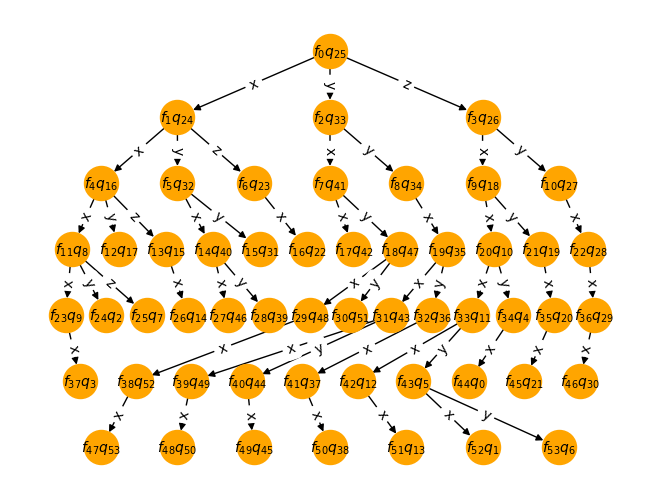

In [14]:
draw_tt(
    graph = bonsai_emerald, 
    type = "spaced", 
    enumeration_scheme = bonsai_emerald.default_enumeration_scheme()
)

In [15]:
bonsai_emerald.n_qubits

54

In [16]:
from ferrmion.optimize.bonsai import bonsai_algorithm

In [17]:
bonsai_emerald = bonsai_algorithm(
    graph = emerald_graph_rx, 
    homogenous = False, 
)

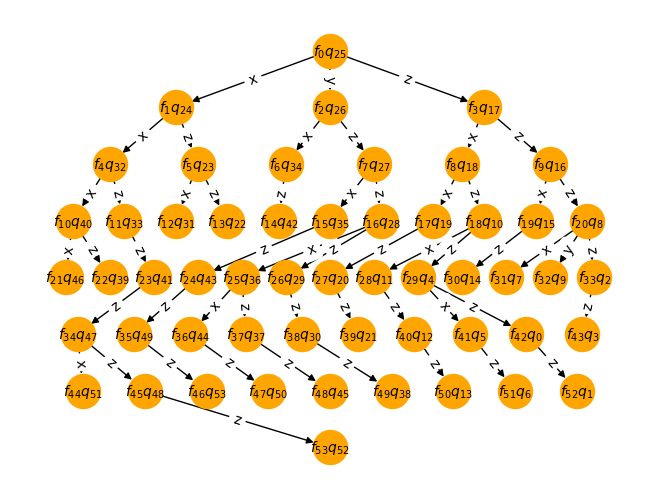

In [18]:
draw_tt(
    graph = bonsai_emerald, 
    type = "spaced", 
    enumeration_scheme = bonsai_emerald.default_enumeration_scheme()
)

In [19]:
print(bonsai_emerald.n_modes)
print(bonsai_emerald.n_qubits)

54
54


In [20]:
bonsai_emerald_truncated = bonsai_algorithm(
    graph = emerald_graph_rx, 
    homogenous = False, 
    max_nodes = 14
)

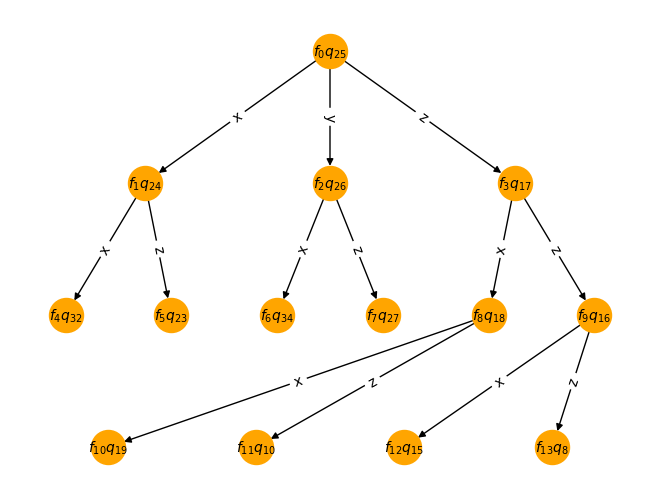

In [21]:
draw_tt(
    graph = bonsai_emerald_truncated, 
    type = "spaced", 
    enumeration_scheme = bonsai_emerald_truncated.default_enumeration_scheme()
)

In [22]:
print(bonsai_emerald_truncated.n_modes)
print(bonsai_emerald_truncated.n_qubits)

14
54


now for garnet

In [1]:
import networkx as nx
import rustworkx as rx
import matplotlib.pyplot as plt
import numpy as np
from enum import Enum

from ferrmion.encode.ternary_tree_node import TTNode
from ferrmion import TernaryTree
from ferrmion.visualise import draw_tt

class LabellingTypes(Enum):
    HOM="homogenous"
    HET="heterogenous"

labelling = LabellingTypes("homogenous")

In [2]:
garnet_edges = [
    (1, 0),
    (1, 4),
    (3, 0),
    (3, 2),
    (3, 4),
    (3, 8),
    (5, 4),
    (5, 6),
    (5, 10),
    (7, 2),
    (7, 8),
    (7, 12),
    (9, 4),
    (9, 8),
    (9, 10),
    (9, 14),
    (11, 6),
    (11, 10),
    (11, 16),
    (13, 8),
    (13, 12),
    (13, 14),
    (13, 17),
    (15, 10),
    (15, 14),
    (15, 16),
    (15, 19),
    (18, 14),
    (18, 17),
    (18, 19)
]

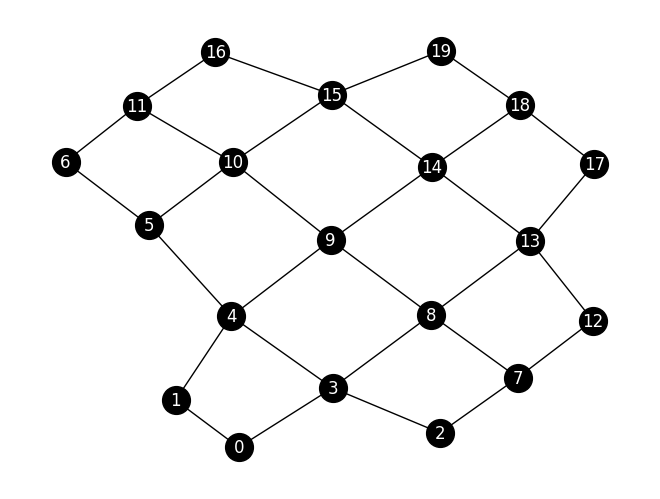

In [3]:
# networkx graph from edges

garnet_graph_nx = nx.Graph()
garnet_graph_nx.add_edges_from(garnet_edges)
layout = nx.spring_layout(garnet_graph_nx, seed=1)

nx.draw(
    G = garnet_graph_nx, 
    pos = layout, 
    node_color = 'black', 
    node_size = 400, 
    with_labels = True, 
    font_color = "white"
)

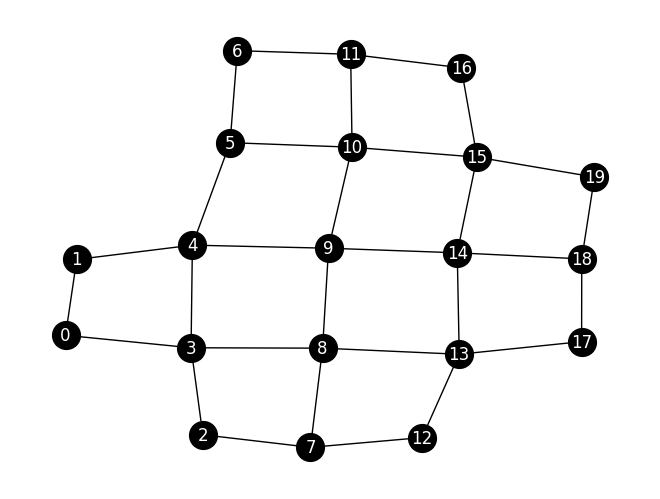

In [4]:
#rustworkx graph from edges (the actual input for bonsai)

garnet_graph_rx = rx.PyGraph()
num_qubits = max(max(pair) for pair in garnet_edges) + 1
garnet_graph_rx.add_nodes_from(range(num_qubits))
garnet_graph_rx.add_edges_from_no_data(garnet_edges)

rx.visualization.mpl_draw(
    graph = garnet_graph_rx, 
    with_labels = True,
    node_color = 'black',
    node_size = 400,
    font_color = 'white',
    pos = rx.spring_layout(garnet_graph_rx, seed=5)
)

In [5]:
graph = garnet_graph_rx

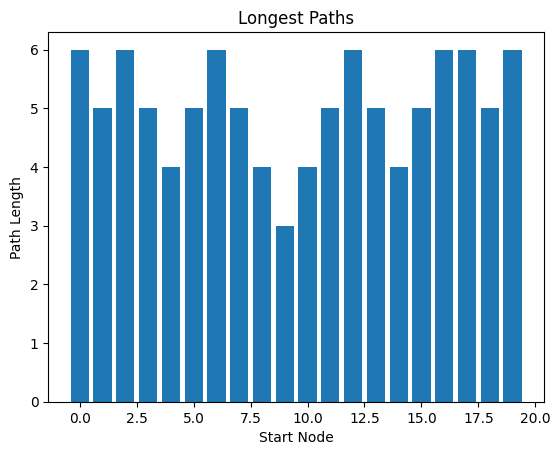

In [6]:
distances = rx.distance_matrix(graph)
plt.bar([*range(distances.shape[1])], np.max(distances, axis=1))
plt.title("Longest Paths")
plt.xlabel("Start Node")
plt.ylabel("Path Length")
plt.show()

In [7]:
# First we find the root 
root_index = np.argmin(np.max(distances, axis=1))
node_queue = [root_index]
used_indices = {root_index}

# Set values for the root node.
nodes = [TTNode(parent=None) for _ in range(graph.num_nodes())]
nodes[root_index].root_path = ""
nodes[root_index].qubit_label = root_index

In [8]:
root_index

np.int64(9)

In [9]:
while len(node_queue)>0:
    node=node_queue.pop(0)
    parent = nodes[node]

    match labelling:
        case LabellingTypes.HOM:
            chars = ["x","y","z"]
        case LabellingTypes.HET:
            chars = ["z","x","y"]
    
    neighbors= list(set(graph.neighbors(node)).difference(used_indices))

    for child in neighbors[:3]:
        node_queue.append(child)
        used_indices.add(child)

    n_neighbors = len(neighbors)
    for neighbor, char in zip(neighbors[:3], chars[:n_neighbors]):
        parent.add_child(char, child_node=nodes[neighbor], root_path=f"{parent.root_path}{char}", qubit_label=neighbor)
        nodes[neighbor].parent = parent

In [10]:
if len(used_indices) == graph.num_nodes():
    print("Tree spans the graph!")
else:
    print("Tree does not span the graph!")
    unused_indices = set(range(graph.num_nodes())).difference(used_indices)
    for unused in unused_indices:
        closest = np.argsort(distances[unused])
        for used in closest:
            used_node: TTNode = nodes[used]
            for child_branch in chars:
                if getattr(used_node, child_branch) is None:
                    used_node.add_child(child_branch, child_node=nodes[unused], root_path=f"{used_node.root_path}{child_branch}", qubit_label=unused)
                    unused_indices.remove(used)
                    break
    if len(unused_indices) > 0:
        print("Error, not all qubits assigned to nodes.")

Tree spans the graph!


In [11]:
nodes

[TTNode (root path:'xxx', Qubit Index:0),
 TTNode (root path:'zx', Qubit Index:1),
 TTNode (root path:'xxy', Qubit Index:2),
 TTNode (root path:'xx', Qubit Index:3),
 TTNode (root path:'z', Qubit Index:4),
 TTNode (root path:'yy', Qubit Index:5),
 TTNode (root path:'yxy', Qubit Index:6),
 TTNode (root path:'xz', Qubit Index:7),
 TTNode (root path:'x', Qubit Index:8),
 TTNode (root path:'', Qubit Index:9),
 TTNode (root path:'y', Qubit Index:10),
 TTNode (root path:'yx', Qubit Index:11),
 TTNode (root path:'xyy', Qubit Index:12),
 TTNode (root path:'xy', Qubit Index:13),
 TTNode (root path:'xyz', Qubit Index:14),
 TTNode (root path:'yz', Qubit Index:15),
 TTNode (root path:'yxx', Qubit Index:16),
 TTNode (root path:'xyx', Qubit Index:17),
 TTNode (root path:'xyxx', Qubit Index:18),
 TTNode (root path:'yzx', Qubit Index:19)]

In [12]:
bonsai_garnet = TernaryTree(graph.num_nodes(), root_node=nodes[root_index])
bonsai_garnet.enumeration_scheme = bonsai_garnet.default_enumeration_scheme()

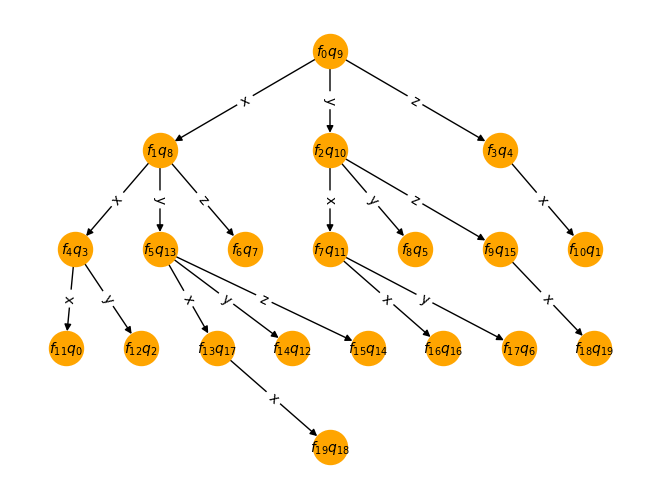

In [13]:
draw_tt(
    graph = bonsai_garnet, 
    type = "spaced", 
    enumeration_scheme = bonsai_garnet.default_enumeration_scheme()
)

In [14]:
bonsai_garnet.n_qubits

20

In [15]:
from ferrmion.optimize.bonsai import bonsai_algorithm

In [16]:
bonsai_garnet = bonsai_algorithm(
    graph = garnet_graph_rx, 
    homogenous = False, 
)

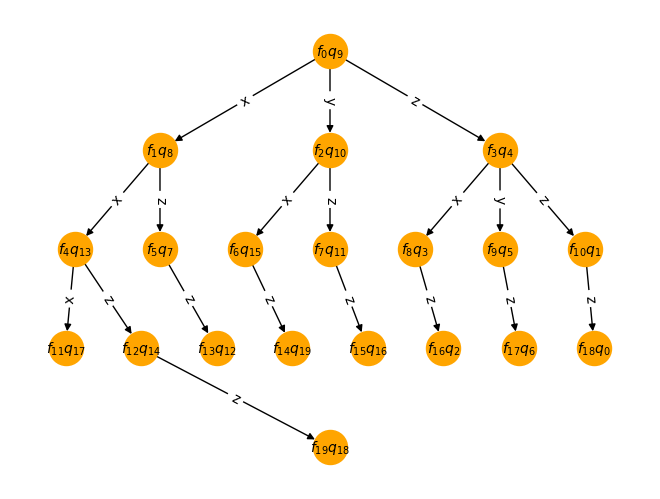

In [17]:
draw_tt(
    graph = bonsai_garnet, 
    type = "spaced", 
    enumeration_scheme = bonsai_garnet.default_enumeration_scheme()
)

In [18]:
print(bonsai_garnet.n_modes)
print(bonsai_garnet.n_qubits)

20
20


In [19]:
bonsai_garnet_truncated = bonsai_algorithm(
    graph = garnet_graph_rx, 
    homogenous = False, 
    max_nodes = 14
)

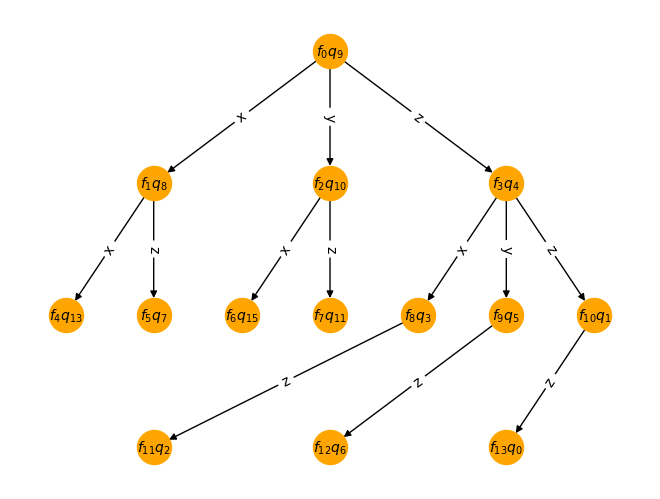

In [20]:
draw_tt(
    graph = bonsai_garnet_truncated, 
    type = "spaced", 
    enumeration_scheme = bonsai_garnet_truncated.default_enumeration_scheme()
)

In [21]:
print(bonsai_garnet_truncated.n_modes)
print(bonsai_garnet_truncated.n_qubits)

14
20


In [22]:
[i for i in range(bonsai_garnet_truncated.n_qubits)]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [23]:
test_edges = [
    (0,1),
    (0,2)
]

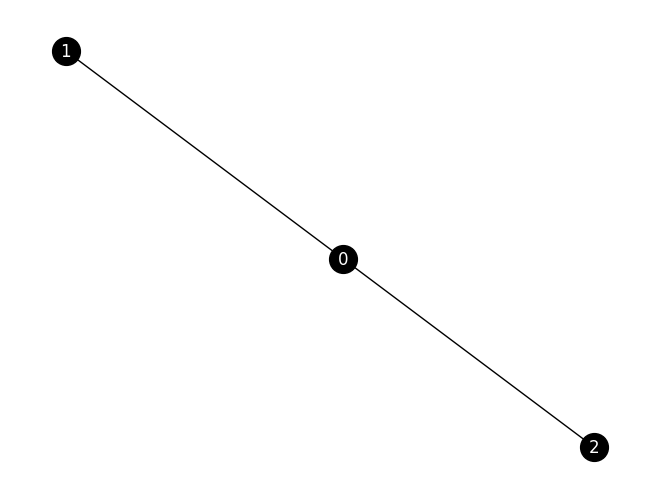

In [24]:
#rustworkx graph from edges (the actual input for bonsai)

test_graph_rx = rx.PyGraph()
num_qubits = max(max(pair) for pair in test_edges) + 1
test_graph_rx.add_nodes_from(range(num_qubits))
test_graph_rx.add_edges_from_no_data(test_edges)

rx.visualization.mpl_draw(
    graph = test_graph_rx, 
    with_labels = True,
    node_color = 'black',
    node_size = 400,
    font_color = 'white',
    pos = rx.spring_layout(test_graph_rx, seed=5)
)

In [25]:
bonsai_test = bonsai_algorithm(
    graph = test_graph_rx, 
    homogenous = False, 
)

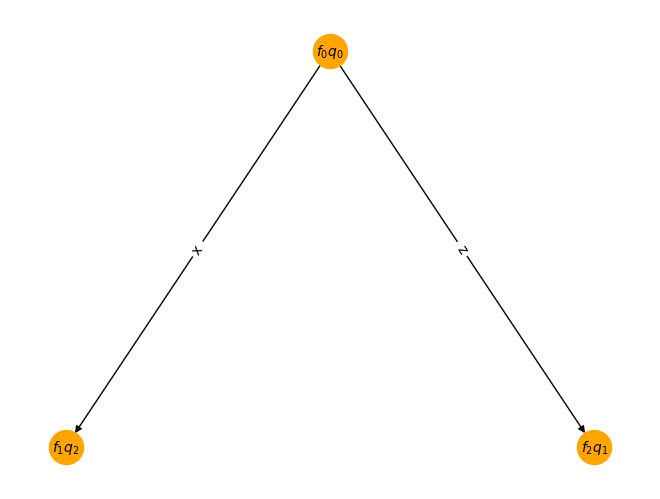

In [26]:
draw_tt(
    graph = bonsai_test, 
    type = "spaced", 
    enumeration_scheme = bonsai_test.default_enumeration_scheme()
)

In [27]:
ham = {
    'XII' : np.sqrt(3)/3,
    'IYI' : np.sqrt(3)/3,
    'IIZ' : np.sqrt(3)/3,
}

In [28]:
qdrift = QDriftSimulation(
    hamiltonian = ham,
    duration = 0.01
)

qc = qdrift.circuit
qc.depth()

NameError: name 'QDriftSimulation' is not defined

In [29]:
qc.draw()

NameError: name 'qc' is not defined

# apply to molecular hams

In [30]:
import pyscf

In [31]:
mol_obj = pyscf.M(
    atom = 'mols/H2O.xyz',
    basis = 'sto-3g'
)

print('qubits =', mol_obj.nao*2)

qubits = 14


In [32]:
rhf_obj = pyscf.scf.RHF(mol_obj).run()

converged SCF energy = -74.9659011922597


In [33]:
from nbed.ham_builder import HamiltonianBuilder

In [34]:
e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

In [35]:
# graph = bonsai_emerald
# graph = bonsai_emerald_truncated

# graph = bonsai_garnet
graph = bonsai_garnet_truncated

In [36]:
graph.n_modes

14

In [37]:
from ferrmion.hamiltonians import molecular_hamiltonian
bonsai_ham = molecular_hamiltonian(
    encoding = graph, 
    one_e_coeffs = one_e_coeffs, 
    two_e_coeffs = two_e_coeffs, 
    constant_energy = e_nuc
)

In [38]:
bonsai_ham

{'IIIIIIIZIIIIIIIZIIII': (-0.14786302562755405+0j),
 'IIIIIIIIIIXZIIIXIIII': (0.0016023626150583523+0j),
 'IIIIIIIIYZIYIIIXIIII': (0.004524501537011269+0j),
 'IIXZZZXXIIIIIIIIIIII': (0.0009644871983424856+0j),
 'IIXZXIIYYXYIIYIIIIII': (-0.009107161087955866+0j),
 'IIXZZZZIIIYZIIIYIIII': (0.004692552350046432+0j),
 'IZIIIIIIIIIIIIIZIIII': (-0.11845329524429249+0j),
 'IZIIYZXIXYIIIXIIIIII': (-0.025362747545937918+0j),
 'IIYZZZYXZZZZIIIIIIII': (0.0009644871983424856+0j),
 'IYZZYIIIIIYXIIIYIIII': (0.010165044071361762+0j),
 'IZXIIIIIIIIIIIIIIIII': (-0.02471111081516574+0j),
 'YZZZIZYIIXZZIIIIIIII': (0.0045221898940258545+0j),
 'IIXZXIIYYXXIIYIYIIII': (0.007496431280096253+0j),
 'IIZZXIIZIXZXIIIIIIII': (-0.0037997780275594445+0j),
 'IIIIIIIIZIIZIZIIIIII': (-0.23827963235237104+0j),
 'IIYZXIZIXYIIIZIIIIII': (-0.001114858203996733+0j),
 'IIZIIIIIIIZIIIIXIIII': (0.01377760729171159+0j),
 'ZZIIIIIIIIIIIIIIIIII': (0.1412257728165384+0j),
 'IXIIZIIIIXZZIIIZIIII': (-0.005032067181999345+0j),
 'IYY

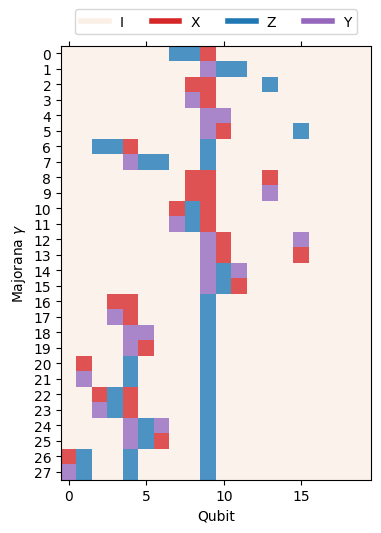

In [39]:
from ferrmion.visualise import draw_tt, symplectic_matshow
symplectic_matshow(graph._build_symplectic_matrix()[1])

In [40]:
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.optimize.topphatt import topphatt
bonsai_topphatt = topphatt(
    majorana_ham = fermionic_to_sparse_majorana(((one_e_coeffs,"+-"), (two_e_coeffs, "++--"))),
    tree = graph
)

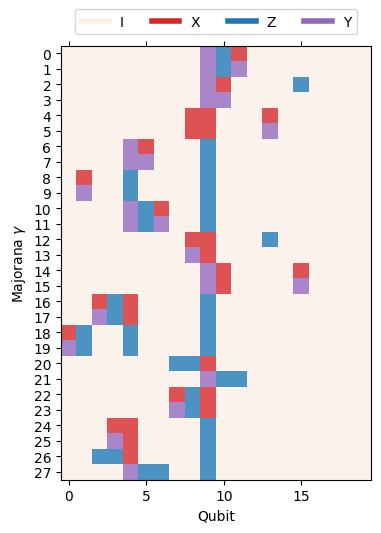

In [41]:
symplectic_matshow(bonsai_topphatt._build_symplectic_matrix()[1])

In [42]:
bonsai_tophatt_ham = molecular_hamiltonian(
    encoding = bonsai_topphatt,
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    constant_energy = e_nuc,
)

In [46]:
bonsai_ham = make_ham_real(bonsai_ham)
bonsai_tophatt_ham = make_ham_real(bonsai_tophatt_ham)

In [47]:
print(list(bonsai_ham)[0], len(list(bonsai_ham)[0]))
print(list(bonsai_tophatt_ham)[0], len(list(bonsai_tophatt_ham)[0]))

IIIIIIIZIIIIIIIZIIII 20
IIIXXYYIYYIIIIIIIIII 20


In [48]:
qdrift = QDriftSimulation(
    hamiltonian = bonsai_ham,
    duration = 0.001
)

qc = qdrift.circuit

In [49]:
qc.depth()

63

In [50]:
import qiskit.qasm2
qiskit.qasm2.dump(qc, "bonsai_ham.qasm")

In [51]:
qdrift = QDriftSimulation(
    hamiltonian = bonsai_tophatt_ham,
    duration = 0.001
)

qc = qdrift.circuit

In [52]:
qc.depth()

25

In [53]:
qiskit.qasm2.dump(qc, "bonsai_topphatt_ham.qasm")

In [54]:
# now build normal JW hams:

In [55]:
jw_tree = JordanWigner(one_e_coeffs.shape[0])

In [56]:
jw_ham = molecular_hamiltonian(
    encoding = jw_tree, 
    one_e_coeffs = one_e_coeffs, 
    two_e_coeffs = two_e_coeffs, 
    constant_energy = e_nuc
)

In [57]:
jw_topphatt_tree = topphatt(
    majorana_ham = fermionic_to_sparse_majorana(((one_e_coeffs,"+-"), (two_e_coeffs, "++--"))),
    tree = jw_tree
)

In [58]:
jw_topphatt_ham = molecular_hamiltonian(
    encoding = jw_topphatt_tree, 
    one_e_coeffs = one_e_coeffs, 
    two_e_coeffs = two_e_coeffs, 
    constant_energy = e_nuc
)

In [59]:
jw_ham = make_ham_real(jw_ham)
jw_topphatt_ham = make_ham_real(jw_topphatt_ham)

In [60]:
qdrift = QDriftSimulation(
    hamiltonian = jw_ham,
    duration = 0.001
)

qc = qdrift.circuit
qc.depth()

23

In [61]:
qiskit.qasm2.dump(qc, "jw_ham.qasm")

In [62]:
qdrift = QDriftSimulation(
    hamiltonian = jw_topphatt_ham,
    duration = 0.001
)

qc = qdrift.circuit
qc.depth()

9

In [63]:
qiskit.qasm2.dump(qc, "jw_topphatt_ham.qasm")

In [64]:
import qiskit
import qiskit.qasm2

In [66]:
bonsai_depths = []
bonsai_topphatt_depths = []
jw_depths = []
jw_topphatt_depths = []

bonsai_depth_best = 1000
bonsai_topphatt_depth_best = 1000
jw_depth_best = 1000
jw_topphatt_depth_best = 1000

dur = 0.001

repeats = 1000

for i in range(repeats):
    qdrift = QDriftSimulation(
        hamiltonian = bonsai_ham,
        duration = dur
    )
    bonsai_depths.append(qdrift.circuit.depth())

    if qdrift.circuit.depth() < bonsai_depth_best:
        bonsai_depth_best = qdrift.circuit.depth()
        bonsai_depth_best_qc = qdrift.circuit

    qdrift = QDriftSimulation(
        hamiltonian = bonsai_tophatt_ham,
        duration = dur
    )
    bonsai_topphatt_depths.append(qdrift.circuit.depth())

    if qdrift.circuit.depth() < bonsai_topphatt_depth_best:
        bonsai_topphatt_depth_best = qdrift.circuit.depth()
        bonsai_topphatt_depth_best_qc = qdrift.circuit

    qdrift = QDriftSimulation(
        hamiltonian = jw_ham,
        duration = dur
    )
    jw_depths.append(qdrift.circuit.depth())

    if qdrift.circuit.depth() < jw_depth_best:
        jw_depth_best = qdrift.circuit.depth()
        jw_depth_best_qc = qdrift.circuit

    qdrift = QDriftSimulation(
        hamiltonian = jw_topphatt_ham,
        duration = dur
    )
    jw_topphatt_depths.append(qdrift.circuit.depth())

    if qdrift.circuit.depth() < jw_topphatt_depth_best:
        jw_topphatt_depth_best = qdrift.circuit.depth()
        jw_topphatt_depth_best_qc = qdrift.circuit


qiskit.qasm2.dump(bonsai_depth_best_qc, "bonsai_depth_best.qasm")
qiskit.qasm2.dump(bonsai_topphatt_depth_best_qc, "bonsai_topphatt_depth_best.qasm")
qiskit.qasm2.dump(jw_depth_best_qc, "jw_depth_best.qasm")
qiskit.qasm2.dump(jw_topphatt_depth_best_qc, "jw_topphatt_depth_best.qasm")

In [67]:
print(bonsai_depth_best)
print(bonsai_topphatt_depth_best)
print(jw_depth_best)
print(jw_topphatt_depth_best)

19
9
3
5


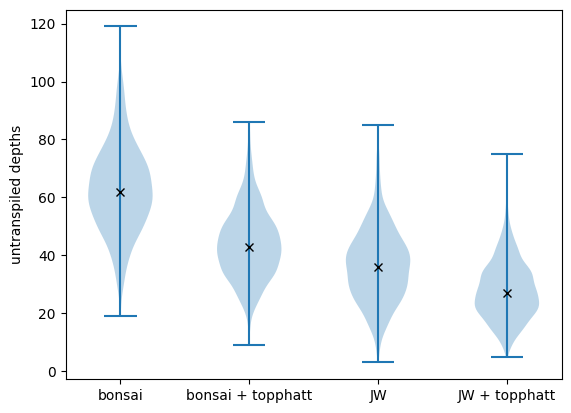

In [68]:
plt.violinplot([
    bonsai_depths, 
    bonsai_topphatt_depths, 
    jw_depths, 
    jw_topphatt_depths
])

plt.xticks([1,2,3,4], ['bonsai', 'bonsai + topphatt', 'JW',  'JW + topphatt'])
plt.ylabel('untranspiled depths')

plt.plot(1, int(np.mean(bonsai_depths)), 'x', color='black')
plt.plot(2, int(np.mean(bonsai_topphatt_depths)), 'x', color='black')
plt.plot(3, int(np.mean(jw_depths)), 'x', color='black')
plt.plot(4, int(np.mean(jw_topphatt_depths)), 'x', color='black')

plt.show()

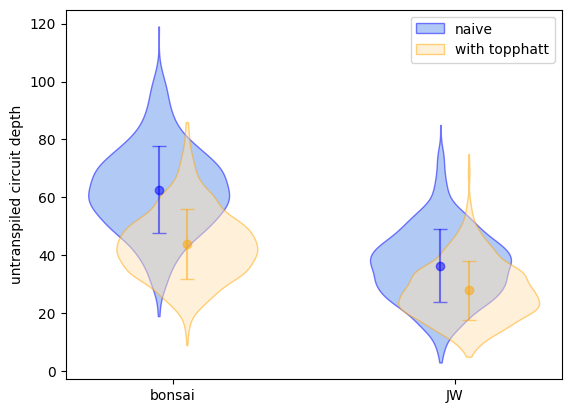

In [138]:
plt.tight_layout()

spacing = 0.05

without_topphatt = plt.violinplot(
    dataset=[
        bonsai_depths, 
        jw_depths, 
    ],
    positions=[1 - spacing, 2 - spacing]
)

with_topphatt = plt.violinplot(
    dataset=[
        bonsai_topphatt_depths, 
        jw_topphatt_depths
    ],
    positions=[1 + spacing, 2 + spacing]
)

alpha=0.5
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
topphatt_edge = 'orange'
topphatt_fill = 'moccasin'


idx = 0
for body in without_topphatt['bodies']:
    body.set_facecolor(naive_fill)
    body.set_edgecolor(naive_edge)
    body.set_alpha(alpha)
    if idx == 0:
        body.set_label('naive')
    idx += 1

idx = 0
for body in with_topphatt['bodies']:
    body.set_facecolor(topphatt_fill)
    body.set_edgecolor(topphatt_edge)
    body.set_alpha(alpha)
    if idx == 0:
        body.set_label('with topphatt')
    idx += 1

plt.errorbar(x=1 - spacing, y=np.mean(bonsai_depths), yerr=np.std(bonsai_depths), fmt='o', color=naive_edge, capsize=5, alpha=alpha)
plt.errorbar(x=1 + spacing, y=np.mean(bonsai_topphatt_depths), yerr=np.std(bonsai_topphatt_depths), fmt='o', color=topphatt_edge, capsize=5, alpha=alpha)

plt.errorbar(x=2 - spacing, y=np.mean(jw_depths), yerr=np.std(jw_depths), fmt='o', color=naive_edge, capsize=5, alpha=alpha)
plt.errorbar(x=2 + spacing, y=np.mean(jw_topphatt_depths), yerr=np.std(jw_topphatt_depths), fmt='o', color=topphatt_edge, capsize=5, alpha=alpha)

without_topphatt['cbars'].set_color('none')
without_topphatt['cmaxes'].set_color('none')
without_topphatt['cmins'].set_color('none')

with_topphatt['cbars'].set_color('none')
with_topphatt['cmaxes'].set_color('none')
with_topphatt['cmins'].set_color('none')

plt.legend()

plt.xticks([1,2], ['bonsai', 'JW'])
plt.ylabel('untranspiled circuit depth')

plt.show()

In [62]:
print(int(np.mean(bonsai_depths)))
print(int(np.mean(bonsai_topphatt_depths)))
print(int(np.mean(jw_depths)))
print(int(np.mean(jw_topphatt_depths)))

139
103
89
75


In [121]:
print(np.std(bonsai_depths))
print(np.std(bonsai_topphatt_depths))
print(np.std(jw_depths))
print(np.std(jw_topphatt_depths))

14.891515671683658
12.09923237234495
12.528865830553059
10.151294252458648


In [92]:
while True:
    qdrift = QDriftSimulation(
        hamiltonian = bonsai_ham,
        duration = dur
    )
    if qdrift.circuit.depth() == int(np.mean(bonsai_depths)):
        qiskit.qasm2.dump(qdrift.circuit, "bonsai_mean.qasm")
        break

print('done bonsai mean')

while True:
    qdrift = QDriftSimulation(
        hamiltonian = bonsai_tophatt_ham,
        duration = dur
    )
    if qdrift.circuit.depth() == int(np.mean(bonsai_topphatt_depths)):
        qiskit.qasm2.dump(qdrift.circuit, "bonsai_topphatt_mean.qasm")
        break

print('done bonsai topphatt mean')

while True:
    qdrift = QDriftSimulation(
        hamiltonian = jw_ham,
        duration = dur
    )
    if qdrift.circuit.depth() == int(np.mean(jw_depths)):
        qiskit.qasm2.dump(qdrift.circuit, "jw_mean.qasm")
        break

print('done jw mean')

while True:
    qdrift = QDriftSimulation(
        hamiltonian = jw_topphatt_ham,
        duration = dur
    )
    if qdrift.circuit.depth() == int(np.mean(jw_topphatt_depths)):
        qiskit.qasm2.dump(qdrift.circuit, "jw_topphatt_mean.qasm")
        break

print('done jw topphatt mean')

done bonsai mean
done bonsai topphatt mean
done jw mean
done jw topphatt mean


# comparison with old NBED ham building

In [194]:
def compare_qdrift_circuit_nbed(
        scf_object,
        constant_energy,
        duration
    ):

    e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
        scf_method=scf_object,
        constant_e_shift=constant_energy
    ).build()

    nbed_ham_old = HamiltonianBuilder_old(
        scf_method=rhf_obj,
        constant_e_shift=mol_obj.energy_nuc()
    ).build()

    converter = HamiltonianConverter_old(nbed_ham_old)
    nbed_ham_symmer = converter.convert('symmer')
    nbed_ham_symmer_dict = nbed_ham_symmer.to_dictionary
    nbed_ham = make_ham_real(nbed_ham_symmer_dict)

    tt = TernaryTree.from_hamiltonian_coefficients((one_e_coeffs, two_e_coeffs))
    jw = tt.JW()
    jw.enumeration_scheme = jw.default_enumeration_scheme()

    JW_ham = molecular_hamiltonian(
        encoding=jw, 
        one_e_coeffs=one_e_coeffs, 
        two_e_coeffs=two_e_coeffs, 
        constant_energy=constant_energy
    )

    JW_ham = make_ham_real(JW_ham)

    majorana_ham = fermionic_to_sparse_majorana(
        [(one_e_coeffs, "+-"), (two_e_coeffs, "++--")]
    )

    TH_tree = topphatt(
        majorana_ham=majorana_ham,
        tree=jw
    )

    TH_ham = molecular_hamiltonian(
        encoding=TH_tree,
        one_e_coeffs=one_e_coeffs,
        two_e_coeffs=two_e_coeffs,
        constant_energy=constant_energy,
    )

    TH_ham = make_ham_real(TH_ham)

    JW_weights = pauli_weights(JW_ham)
    TH_weights = pauli_weights(TH_ham)
    nbed_weights = pauli_weights(nbed_ham)

    JW_lambda = float(np.sum(np.abs(JW_weights[1])))
    TH_lambda = float(np.sum(np.abs(TH_weights[1])))
    nbed_lambda = float(np.sum(np.abs(nbed_weights[1])))

    print("mean JW weights:", int(np.mean(JW_weights[0])), float(np.mean(JW_weights[1])), int(JW_weights[2]))
    print("mean TH weights:", int(np.mean(TH_weights[0])), float(np.mean(TH_weights[1])), int(TH_weights[2]))
    print("mean nbed weights:", int(np.mean(nbed_weights[0])), float(np.mean(nbed_weights[1])), int(nbed_weights[2]))

    print('JW lambda^2:', JW_lambda**2)
    print('TH lambda^2:', TH_lambda**2)
    print('nbed lambda^2:', nbed_lambda**2)

    QD_JW = QDriftSimulation(
        hamiltonian=JW_ham,
        duration=duration
    )

    QD_TH = QDriftSimulation(
        hamiltonian=TH_ham,
        duration=duration
    )

    QD_nbed = QDriftSimulation(
        hamiltonian=nbed_ham,
        duration=duration
    )

    return QD_JW.circuit.depth(), QD_TH.circuit.depth(), QD_nbed.circuit.depth()

In [195]:
mol_obj = pyscf.M(
    atom = 'mols/H2O.xyz',
    basis = 'sto-3g'
)

rhf_obj = pyscf.scf.RHF(mol_obj).run()

converged SCF energy = -74.9659011922597


In [196]:
JW_depth, TH_depth, nbed_depth = compare_qdrift_circuit_nbed(
    scf_object=rhf_obj,
    constant_energy=mol_obj.energy_nuc(),
    duration=0.03
)
print()
print('JW depth:', JW_depth)
print('TH depth:', TH_depth)
print('nbed depth:', nbed_depth)

2025-11-11 12:39:07,085: ham_builder: 328: WARNING: Tapering is deprecated. Use the qubit_reduction_driver.


mean JW weights: 7 0.17621337145046764 1086
mean TH weights: 4 0.12705021266991032 1086
mean nbed weights: 7 0.17621337145046767 1086
JW lambda^2: 36621.6047919939
TH lambda^2: 19037.523095624096
nbed lambda^2: 36621.60479199391

JW depth: 28556
TH depth: 21214
nbed depth: 25861


# molecule suite from hatt paper

In [117]:
mol_obj = pyscf.M(
    atom = 'mols/CO2.xyz',
    basis = 'sto-3g'
)

rhf_obj = pyscf.scf.RHF(mol_obj).run()

converged SCF energy = -185.068390456989


In [118]:
e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

In [119]:
JW_depth, TH_depth, _ = compare_qdrift_circuit(
    one_e_coeffs, 
    two_e_coeffs, 
    e_nuc,
    duration=0.01
)

mean JW weights: 13 0.0796783478105783 16170
mean TH weights: 9 0.06065965565087854 16170
JW lambda^2: 1659971.6845425263
TH lambda^2: 962099.3495252299
TH shoud be smaller by factor: 1.7253641064840939


In [120]:
print('JW depth:', JW_depth)
print('TH depth:', TH_depth)

JW depth: 55108
TH depth: 43809


In [ ]:
depths = np.arange(0.001, 0.011, 0.001)
depths

array([0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009,
       0.01 ])

In [ ]:
JW_depths = []
TH_depths = []

for depth in depths:
    JW_d, TH_d, _ = compare_qdrift_circuit(
        one_e_coeffs, 
        two_e_coeffs, 
        e_nuc,
        duration=depth
        )
    JW_depths.append(JW_d)
    TH_depths.append(TH_d)
    print('done', depth)


mean JW weights: 9 0.12017965896038975 2951
mean TH weights: 7 0.09248231710070788 2951
JW lambda^2: 125776.74562891386
TH lambda^2: 74482.77067032823
TH shoud be smaller by factor: 1.6886689968290836
done 0.001
mean JW weights: 9 0.12017965896038975 2951
mean TH weights: 7 0.09248231710070788 2951
JW lambda^2: 125776.74562891386
TH lambda^2: 74482.77067032823
TH shoud be smaller by factor: 1.6886689968290836
done 0.002
mean JW weights: 9 0.12017965896038975 2951
mean TH weights: 7 0.09248231710070787 2951
JW lambda^2: 125776.74562891386
TH lambda^2: 74482.7706703282
TH shoud be smaller by factor: 1.6886689968290842
done 0.003
mean JW weights: 9 0.12017965896038975 2951
mean TH weights: 7 0.09248231710070787 2951
JW lambda^2: 125776.74562891386
TH lambda^2: 74482.7706703282
TH shoud be smaller by factor: 1.6886689968290842
done 0.004
mean JW weights: 9 0.12017965896038975 2951
mean TH weights: 7 0.09248231710070788 2951
JW lambda^2: 125776.74562891386
TH lambda^2: 74482.77067032823
TH 

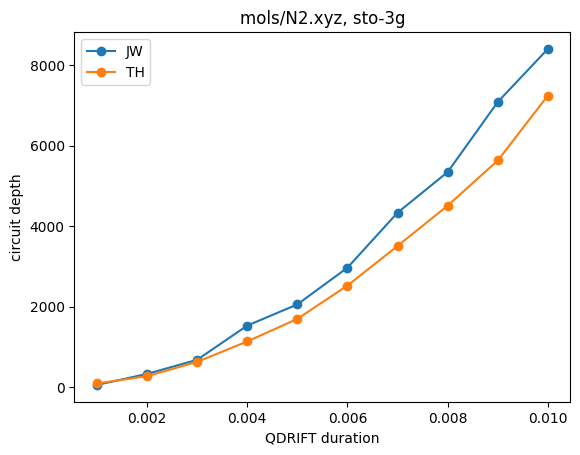

In [ ]:
plt.plot(depths, JW_depths, label='JW', marker='o')
plt.plot(depths, TH_depths, label='TH', marker='o')

plt.xlabel('QDRIFT duration')
plt.ylabel('circuit depth')
plt.title(', '.join([mol_obj.atom, mol_obj.basis]))

plt.legend()

plt.show()